In [72]:
# Install requirements 
# ! pip install pandas numpy matplotlib scikit-learn imblearn gspread oauth2client yellowbrick seaborn torch

In [73]:
# Import requirements
import os
import gspread
from jupyter_core.migrate import regex
from oauth2client.service_account import ServiceAccountCredentials
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy._lib.array_api_compat import torch

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV)
from sklearn import (
    preprocessing,
    cluster,
    datasets,
    mixture)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, 
    RocCurveDisplay,
    roc_curve, 
    precision_recall_curve,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix)

from yellowbrick.classifier import ClassificationReport, ConfusionMatrix
from yellowbrick.features import RadViz
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [74]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.6.0+cu126
CUDA available: True
Using GPU: NVIDIA GeForce RTX 4090


In [75]:
# Ensure code is running on GPU
import torch

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

print("Is CUDA available?", torch.cuda.is_available())
print("Current device:", torch.cuda.get_device_name(0))



Using GPU: NVIDIA GeForce RTX 4090
Is CUDA available? True
Current device: NVIDIA GeForce RTX 4090


In [76]:
from plotting_utilities import (
    plot_roc, 
    precision_recall_threshold, 
    create_feature_heatmap, 
    classifier_corrplot, 
    plot_feature_importances)
from utilities import preprocess_column_name

In [77]:
# The credential Json file contains the necessary credentials for connecting to drive 
# and downloading the model_kernel_cin_cout worksheet from the tornadovm-online-model
# google sheet. 

# Alternatively, it can be also downloaded locally as a csv and loaded in a pandas dataframe
'''
root_dir = os.path.abspath(os.curdir)
credential_file = os.path.join(root_dir, 'tornadovm-ml.json')

scope = ['https://spreadsheets.google.com/feeds',
         'https://www.googleapis.com/auth/drive']
creds = ServiceAccountCredentials.from_json_keyfile_name(credential_file, scope)
client = gspread.authorize(creds)

sheet = client.open("tornadovm-online-model").worksheet("model_kernel_cin_cout")'''
import pandas as pd
import os


# Load the dataset from the provided URL
dropbox_url = "https://www.dropbox.com/scl/fi/6g10ofcakh1dxn2rz938l/18thJune.csv?rlkey=wy773o1jwetb7y1rdgvpwzpop&st=ueuk8sgy&dl=1"


# Load the dataset from the provided URL
df = pd.read_csv(dropbox_url)


In [78]:
# Load dataset into a pandas dataframe
# df=pd.DataFrame(sheet.get_all_records())

# Data Preprocessing: Cleaning & Feature Engineering

In [79]:
# Convert dataset's column into lowercase & snake case
column_names=[preprocess_column_name(name) for name in df.columns]
df.columns=column_names
df.head()

,workload_name,threads,cpu_time,cpu_energy,gpu_time,gpu_energy,igpu_time,igpu_energy,java_time,java_energy,...,total_integer_operations,total_float_operations,single_precision_float_operations,double_precision_float_operations,binary_operations,boolean_operations,float_math_functions,integer_math_functions,integer_comparison,float_comparison
0,saxpy,512,144522.1,2580.0,121753.6,883.0,223751.0,1585.0,12693.40,0.0,...,3,0,0,0,0,0,0,0,1,0
1,saxpy,1024,139910.5,2481.0,124347.0,1006.0,214745.7,1521.0,24860.91,1005.0,...,3,0,0,0,0,0,0,0,1,0
2,saxpy,2048,155461.1,2408.0,128984.4,926.0,224993.4,1469.0,91430.39,0.0,...,3,0,0,0,0,0,0,0,1,0
3,saxpy,4096,125564.7,2375.0,125801.8,904.0,240731.4,1608.0,98132.36,0.0,...,3,0,0,0,0,0,0,0,1,0
4,saxpy,8192,143968.3,2129.0,130519.3,908.0,263388.3,1557.0,49850.94,0.0,...,3,0,0,0,0,0,0,0,1,0


### Remove features with std 0 and engineer new features

In [80]:
# Combine workload_name and threads features into one. 
# E.g., mandelbrot_64, madelbrot_128 etc. 
# This is useful as the unique identifier of each training example
df["workload"] = df["workload_name"] +"_"+ df["threads"].astype(str)

# Clear contains 0 values
cols_of_interest = ['cpu_time','gpu_time','igpu_time']
df = df[(df[cols_of_interest] != 0).all(axis=1)]

# Drop NaN values
# Uncomment for general situation
# df = df.dropna()

# Only for Java energy missed situation
df = df.dropna(subset=cols_of_interest)

# Feature Engineering
# Creation of 5 new features through summation of existing ones
# "low_cost_operations": Sum of "private_memory_loads" & "private_memory_stores"
# "control_flow_operations": sum of 'if_statements', 'switch_statements', 'switch_cases',
#                           'integer_comparison', 'float_comparison'
# "math_functions": sum of "float_math_functions", "integer_math_functions"
# "global_memory_operations": sum of "global_memory_loads" & "global_memory_stores"
# "local_memory_operations": sum of "local_memory_loads" & "local_memory_stores"
low_cost_operations = ["private_memory_loads", "private_memory_stores"]
control_flow_operations = ['if_statements', 'switch_statements', 'switch_cases', 'integer_comparison', 'float_comparison']
df["low_cost_operations"] = df["private_memory_loads"]+df["private_memory_stores"]
df["control_flow_operations"] = df["if_statements"]+df["switch_statements"]+df["switch_cases"]+df["integer_comparison"]+df["float_comparison"]
df["math_functions"] = df["float_math_functions"] + df["integer_math_functions"]
df["global_memory_operations"] = df["global_memory_loads"] + df["global_memory_stores"]
df["local_memory_operations"] = df["local_memory_loads"] + df["local_memory_stores"]

# Identify features with 0 standard deviation so that we can remove them. Std=0 means that this feature has the same 
# value for every training example in the dataset and so it contains no information.
df_stats=df.describe().T
std_0_fetaures = list(df_stats.loc[df_stats['std'] == 0].reset_index()['index'])

# Remove from the dataset :
# 1. features with std=0, 
# 2. low_cost_operations feature, control_flow_operations  (during experiments appeared to be not useful)
# Keep proteced_columns
protected_columns = ['local_memory_loads', 'local_memory_stores', 'vector_operations']

# Ensure keep the protected columns
columns_to_drop = list(set(std_0_fetaures) - set(protected_columns))

# Define the final dataset
df_cleaned = df.drop(columns=columns_to_drop + low_cost_operations + control_flow_operations)
df_cleaned = df_cleaned.fillna(0)
workload_cols = df_cleaned[["workload_name", "workload"]]
df_cleaned = df_cleaned.drop(columns=["workload_name", "workload"])


# Continue with Feature Engineering
# Add polynomial interaction features, e.g. pairwise combination of the existing ones
polyFeatures = preprocessing.PolynomialFeatures(2, interaction_only=True)
polyFeatDF = polyFeatures.fit_transform(df_cleaned)
df_enhanced = pd.DataFrame(polyFeatDF)
df_enhanced.columns = list(polyFeatures.get_feature_names_out(input_features=df_cleaned.columns))
df_cleaned = df_enhanced
df_cleaned = pd.concat([df_cleaned,workload_cols],axis=1).drop(columns=["1"])
df_cleaned.head()
df_cleaned = df_cleaned.applymap(lambda x: x.lower() if isinstance(x, str) else x)
print(df_cleaned["workload"].tolist())



['saxpy_512', 'saxpy_1024', 'saxpy_2048', 'saxpy_4096', 'saxpy_8192', 'saxpy_16384', 'saxpy_32768', 'saxpy_65536', 'saxpy_131072', 'saxpy_262144', 'saxpy_524288', 'saxpy_1048576', 'saxpy_2097152', 'saxpy_4194304', 'saxpy_8388608', 'saxpy_16777216', 'saxpy_33554432', 'saxpy_67108864', 'add-image_64', 'add-image_128', 'add-image_256', 'add-image_512', 'add-image_1024', 'add-image_2048', 'add-image_4096', 'add-image_8192', 'stencil_65536', 'stencil_131072', 'stencil_262144', 'stencil_524288', 'stencil_1048576', 'stencil_2097152', 'stencil_4194304', 'stencil_8388608', 'stencil_16777216', 'stencil_33554432', 'stencil_67108864', 'convolve-array_64', 'convolve-array_128', 'convolve-array_256', 'convolve-array_512', 'convolve-array_1024', 'convolve-array_2048', 'convolve-array_4096', 'convolve-array_8192', 'convolve-image_64', 'convolve-image_128', 'convolve-image_256', 'convolve-image_512', 'convolve-image_1024', 'convolve-image_2048', 'convolve-image_4096', 'convolve-image_8192', 'blackschol

In [81]:
df_cleaned.head()
print(df.columns.tolist())

['workload_name', 'threads', 'cpu_time', 'cpu_energy', 'gpu_time', 'gpu_energy', 'igpu_time', 'igpu_energy', 'java_time', 'java_energy', 'igpu_cpu', 'gpu_cpu', 'igpu_gpu', 'gpu_igpu', 'gpu_igu_energy', 'igpu_gpu_energy', 'gpu_cpu_energy', 'igpu_cpu_energy', 'java_igpu', 'java_gpu', 'java_cpu', 'java_igpu_energy', 'java_gpu_energy', 'java_cpu_energy', 'gpu_igpu_energy', 'global_memory_loads', 'global_memory_stores', 'local_memory_loads', 'local_memory_stores', 'constant_memory_loads', 'constant_memory_stores', 'private_memory_loads', 'private_memory_stores', 'total_loops', 'parallel_loops', 'if_statements', 'switch_statements', 'switch_cases', 'cast_operations', 'vector_operations', 'total_integer_operations', 'total_float_operations', 'single_precision_float_operations', 'double_precision_float_operations', 'binary_operations', 'boolean_operations', 'float_math_functions', 'integer_math_functions', 'integer_comparison', 'float_comparison', 'workload', 'low_cost_operations', 'control_fl

In [82]:
total_features = [ x for x in list(df_cleaned.columns) if ("cpu" not in x and "gpu" not in x and "igpu" not in x and "workload_name" not in x and "workload" not in x)]
print(f"The number of features in the dataset is: {len(total_features)}")

The number of features in the dataset is: 231


### Compute features' Pearson (linear) correlations

In [83]:
# Uncomment to generate feature heatmap
# create_feature_heatmap(df_cleaned, save_file="heatmap.pdf")

In [84]:
# "Workloads" dict contains the information which workloads will be used as test set for the model evaluation.
# These workloads will not be used for training.
# Sample format: workloads = {
#                             "workload_1_low": ["DFT_1024", "BlackScholes_131072", "MatrixMultiplication1D_256"],
#                             "workload_1_medium": ["DFT_4096", "BlackScholes_524288", "MatrixMultiplication1D_512"]
#                             }
workloads = {}

# Group 1: Compute-Intensive
# Workloads are "dgemm", sgemm, matrixMultiplication1D, matrixMultiplication2D, dot-vector, dot-image, dft, juliaSet, euler, nbody
workloads["workload_1_low"]=["sgemm_64", "matrixmultiplication1d_64", "matrixmultiplication2d_64", "dot-vector_1048576", "dot-image_256", "dft_256", "juliaset_512", "euler_16", "nbody_256"]
workloads["workload_1_medium"]=[ "sgemm_512", "matrixmultiplication1d_512", "matrixmultiplication2d_512", "dot-vector_4194304", "dot-image_1024", "dft_4096", "juliaset_2048", "euler_64", "nbody_4096"]
workloads["workload_1_high"]=["sgemm_4096", "matrixmultiplication1d_4096", "matrixmultiplication2d_4096", "dot-vector_33554432", "dot-image_8192", "dft_65536", "juliaset_8192", "euler_256", "nbody_32768"]

# Group 2: Mixed-Intensive
# Workloads are saxpy, hilbert, bfs, integration, rotate-vector, maxReductionGlobal, maxReductionLocal, vectorAdditionFloat4, blackAndWhiteFilter, renderTrack, rotate-image
workloads["workload_2_low"]=["saxpy_512", "hilbert_16", "bfs_256", "integration_65536", "rotate-vector_1048576", "maxreductionglobal_65536", "maxreductionlocal_65536", "vectoradditionfloat4_65536", "blackandwhitefilter_256", "rendertrack_64", "rotate-image_256"]
workloads["workload_2_medium"]=["saxpy_524288", "hilbert_256", "bfs_2048", "integration_2097152", "rotate-vector_4194304", "maxreductionglobal_4194304", "maxreductionlocal_2097152", "vectoradditionfloat4_2097152", "blackandwhitefilter_2048", "rendertrack_1024", "rotate-image_1024"]
workloads["workload_2_high"]=["saxpy_67108864", "hilbert_2048", "bfs_16384", "integration_67108864", "rotate-vector_33554432", "maxreductionglobal_67108864", "maxreductionlocal_67108864", "vectoradditionfloat4_67108864", "blackandwhitefilter_16384", "rendertrack_8192", "rotate-image_8192"]

# Group 3: Memory/Data-Intensive
# Workloads are vectorAddition, matrixVectorMultiplication, matrix addition, matrix transpose, convolve-array, convolve-image, stencil, blurFilter, add-image, blacksholes
workloads["workload_3_low"]=["vectoraddition_65536", "matrixvectormultiplication_64", "matrixaddition_64", "matrixtranspose_64", "convolve-array_64", "convolve-image_64", "stencil_65536", "blurfilter_256", "add-image_64", "blackscholes_512"]
workloads["workload_3_medium"]=["vectoraddition_2097152", "matrixvectormultiplication_512", "matrixaddition_512", "matrixtranspose_512", "convolve-array_1024", "convolve-image_1024", "stencil_2097152", "blurfilter_1024", "add-image_512", "blackscholes_131072"]
workloads["workload_3_high"]=["vectoraddition_67108864", "matrixvectormultiplication_4096", "matrixaddition_4096", "matrixtranspose_4096", "convolve-array_8192", "convolve-image_8192", "stencil_67108864", "blurfilter_8192", "add-image_4096", "blackscholes_67108864"]

full_workloads = workloads["workload_1_low"]+workloads["workload_1_medium"]+workloads["workload_1_high"]+workloads["workload_2_low"]+workloads["workload_2_medium"]+workloads["workload_2_high"]+workloads["workload_3_low"]+workloads["workload_3_medium"]+workloads["workload_3_high"]
df_cleaned.head()


,threads,cpu_time,cpu_energy,gpu_time,gpu_energy,igpu_time,igpu_energy,java_time,java_energy,igpu_cpu,...,low_cost_operations global_memory_operations,low_cost_operations local_memory_operations,control_flow_operations math_functions,control_flow_operations global_memory_operations,control_flow_operations local_memory_operations,math_functions global_memory_operations,math_functions local_memory_operations,global_memory_operations local_memory_operations,workload_name,workload
0,512.0,144522.1,2580.0,121753.6,883.0,223751.0,1585.0,12693.40,0.0,0.645906,...,48.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,saxpy,saxpy_512
1,1024.0,139910.5,2481.0,124347.0,1006.0,214745.7,1521.0,24860.91,1005.0,0.651517,...,48.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,saxpy,saxpy_1024
2,2048.0,155461.1,2408.0,128984.4,926.0,224993.4,1469.0,91430.39,0.0,0.690958,...,48.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,saxpy,saxpy_2048
3,4096.0,125564.7,2375.0,125801.8,904.0,240731.4,1608.0,98132.36,0.0,0.521597,...,48.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,saxpy,saxpy_4096
4,8192.0,143968.3,2129.0,130519.3,908.0,263388.3,1557.0,49850.94,0.0,0.546601,...,48.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,saxpy,saxpy_8192


In [85]:
# Create left_out dataframe which contains data points that will be used during testing
# Remove from the dataset all data points present in the left_out so that they will not be used during training
df_cleaned=df_cleaned.set_index("workload")
left_out = df_cleaned.loc[full_workloads , : ]
df_cleaned = df_cleaned.drop(full_workloads).reset_index()
left_out = left_out.reset_index()


#print("df_cleaned df:")
#print(df_cleaned.head())

In [86]:
print("Left out df:")
left_out.head()
df_cleaned = df_cleaned.dropna()

print(df_cleaned.columns.tolist())

Left out df:
['workload', 'threads', 'cpu_time', 'cpu_energy', 'gpu_time', 'gpu_energy', 'igpu_time', 'igpu_energy', 'java_time', 'java_energy', 'igpu_cpu', 'gpu_cpu', 'igpu_gpu', 'gpu_igpu', 'gpu_igu_energy', 'igpu_gpu_energy', 'gpu_cpu_energy', 'igpu_cpu_energy', 'java_igpu', 'java_gpu', 'java_cpu', 'java_igpu_energy', 'java_gpu_energy', 'java_cpu_energy', 'gpu_igpu_energy', 'global_memory_loads', 'global_memory_stores', 'local_memory_loads', 'local_memory_stores', 'total_loops', 'parallel_loops', 'cast_operations', 'vector_operations', 'total_integer_operations', 'total_float_operations', 'single_precision_float_operations', 'float_math_functions', 'integer_math_functions', 'low_cost_operations', 'control_flow_operations', 'math_functions', 'global_memory_operations', 'local_memory_operations', 'threads cpu_time', 'threads cpu_energy', 'threads gpu_time', 'threads gpu_energy', 'threads igpu_time', 'threads igpu_energy', 'threads java_time', 'threads java_energy', 'threads igpu_cpu',

In [87]:
# During experimentation we concluded that the top 10 most useful features per classifiers are the ones included in
# following lists.
clf_1_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_2_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_3_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
            "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_4_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
             "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_5_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
             "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

clf_6_top = ["threads", "global_memory_loads", "global_memory_stores", "local_memory_loads", "local_memory_stores",
             "total_loops", "parallel_loops", "cast_operations", "vector_operations", "total_integer_operations"]

# If you want to experiment again with all the available features comment in the following lines
# clf_1_top,  clf_2_top, clf_3_top = 3*total_features


# Modeling with ExtraTreesClassifiers

# Classifier 1: IGPU vs CPU

[clf1] Best params: {'max_depth': 5, 'n_estimators': 500}
[clf1] Best MSE (cv): 0.6259993770711263
[clf1] In-sample MSE: 0.3104, accuracy: 0.7935
[clf1] Test     MSE: 0.5363, accuracy: 0.6265

[clf1] === Classification Report ===
              precision    recall  f1-score   support

        iGPU       0.50      0.26      0.34        31
         CPU       0.66      0.85      0.74        52

    accuracy                           0.63        83
   macro avg       0.58      0.55      0.54        83
weighted avg       0.60      0.63      0.59        83



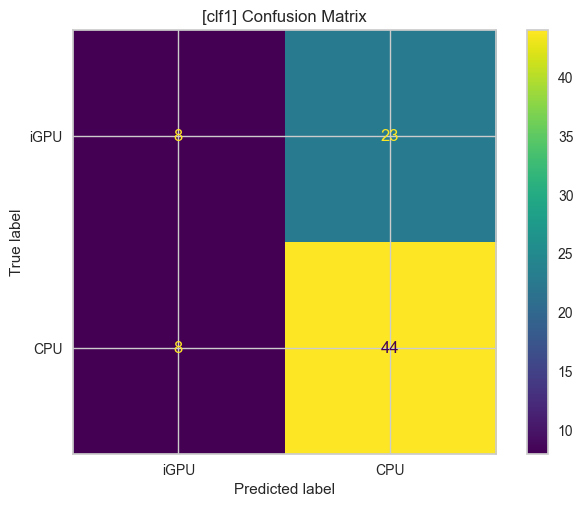

In [88]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===================== Classifier 1: iGPU vs CPU Energy (Log-ratio Regression) =====================

# Data preparation for classifier 1
clf1_df = df_cleaned.copy()
clf1_df = clf1_df[clf1_df['igpu_cpu_energy'] != 1]  # Remove invalid ratios
clf1_clip_max = 4  # Cap extreme values for log-ratio calculation

# Compute log-ratio for regression
clf1_df['clf1_log_ratio'] = np.log(np.clip(clf1_df['igpu_cpu_energy'], 1e-8, clf1_clip_max))

# Define binary ground truth for classifier 1 (iGPU better=0, CPU better=1)
clf1_df['clf1_target'] = np.where(clf1_df['igpu_cpu_energy'] < 1, 0, 1)

# Feature selection
clf1_X_train = clf1_df[clf_1_top]
clf1_y_train_logratio = clf1_df['clf1_log_ratio']
clf1_y_train_label = clf1_df['clf1_target']

# Test set preparation for classifier 1
clf1_left_out = left_out.dropna(subset=['cpu_energy', 'igpu_energy', 'igpu_cpu_energy'])
clf1_X_test = clf1_left_out[clf_1_top + ['igpu_cpu_energy', 'cpu_energy', 'igpu_energy']]
clf1_X_test = clf1_X_test[clf1_X_test['igpu_cpu_energy'] != 1]
clf1_y_test_logratio = np.log(np.clip(clf1_X_test['igpu_cpu_energy'], 1e-8, clf1_clip_max))
clf1_y_test_label = np.where(clf1_X_test['igpu_cpu_energy'] < 1, 0, 1)
clf1_X_test = clf1_X_test[clf_1_top]

# Regression model & hyperparameter grid
clf1_param_grid = {
    'n_estimators': [50, 100, 500],
    'max_depth': [5, 10, 50]
}
clf1_grid = GridSearchCV(
    RandomForestRegressor(random_state=0),
    clf1_param_grid,
    cv=10,
    scoring='neg_mean_squared_error'
)
clf1_grid.fit(clf1_X_train, clf1_y_train_logratio)
clf1_reg = clf1_grid.best_estimator_

print('[clf1] Best params:', clf1_grid.best_params_)
print('[clf1] Best MSE (cv):', -clf1_grid.best_score_)

# Regression predictions and binary conversion
clf1_train_pred_logratio = clf1_reg.predict(clf1_X_train)
clf1_train_pred_label = (clf1_train_pred_logratio > 0).astype(int)  # log(ratio)>0 => recommend CPU

clf1_test_pred_logratio = clf1_reg.predict(clf1_X_test)
clf1_test_pred_label = (clf1_test_pred_logratio > 0).astype(int)

clf1_train_mse = mean_squared_error(clf1_y_train_logratio, clf1_train_pred_logratio)
clf1_test_mse = mean_squared_error(clf1_y_test_logratio, clf1_test_pred_logratio)
clf1_train_acc = accuracy_score(clf1_y_train_label, clf1_train_pred_label)
clf1_test_acc = accuracy_score(clf1_y_test_label, clf1_test_pred_label)

print(f'[clf1] In-sample MSE: {clf1_train_mse:.4f}, accuracy: {clf1_train_acc:.4f}')
print(f'[clf1] Test     MSE: {clf1_test_mse:.4f}, accuracy: {clf1_test_acc:.4f}')

# Classification Report
print("\n[clf1] === Classification Report ===")
print(classification_report(clf1_y_test_label, clf1_test_pred_label, target_names=["iGPU", "CPU"]))

# Confusion Matrix
clf1_cm = confusion_matrix(clf1_y_test_label, clf1_test_pred_label)
clf1_disp = ConfusionMatrixDisplay(confusion_matrix=clf1_cm, display_labels=["iGPU", "CPU"])
clf1_disp.plot()
plt.title("[clf1] Confusion Matrix")
plt.show()


In [89]:
# ===================== clf1: Misclassified samples analysis =====================
clf1_test_analysis = clf1_X_test.copy()
# Add ratio from the raw dataset for test set
clf1_test_analysis['clf1_ratio'] = clf1_left_out.loc[clf1_X_test.index, 'igpu_cpu_energy'].values
clf1_test_analysis['clf1_true_label'] = clf1_y_test_label
clf1_test_analysis['clf1_pred_label'] = clf1_test_pred_label

clf1_mis_idx = np.where(clf1_test_analysis['clf1_pred_label'] != clf1_test_analysis['clf1_true_label'])[0]
clf1_misclassified_samples = clf1_test_analysis.iloc[clf1_mis_idx].copy()
clf1_cols_to_show = clf_1_top + ['clf1_ratio', 'clf1_true_label', 'clf1_pred_label']
print("==== [clf1] Hard misclassified test samples ====")
print(clf1_misclassified_samples[clf1_cols_to_show].head(20))

# Option to save misclassified samples to a CSV file
# clf1_misclassified_samples[clf1_cols_to_show].to_csv('clf1_misclassified_test_samples.csv', index=False)


==== [clf1] Hard misclassified test samples ====
      threads  global_memory_loads  global_memory_stores  local_memory_loads  \
6    262144.0                  0.0                   2.0                 0.0   
7        16.0                  2.0                   0.0                 0.0   
12     2048.0                  0.0                   1.0                 0.0   
14     2048.0                  0.0                   2.0                 0.0   
15  1048576.0                  0.0                   2.0                 0.0   
19     4096.0                  2.0                   1.0                 0.0   
23   131072.0                  0.0                   2.0                 0.0   
30  8388608.0                  2.0                   1.0                 3.0   
32  8388608.0                  3.0                   2.0                 0.0   
37     1024.0                  2.0                   1.0                 0.0   
41      512.0                  3.0                   0.0               

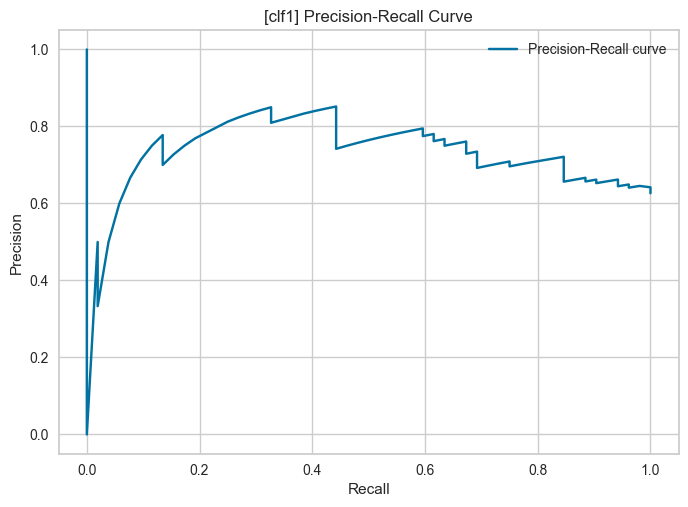

In [90]:
# ===================== clf1: Precision-Recall curve =====================
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

clf1_y_scores = clf1_test_pred_logratio  # log-ratio as the score
clf1_p, clf1_r, clf1_thresholds = precision_recall_curve(clf1_y_test_label, clf1_y_scores)

plt.figure()
plt.plot(clf1_r, clf1_p, label="Precision-Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("[clf1] Precision-Recall Curve")
plt.legend()
plt.show()


In [91]:
# ===================== clf1: Restore test set predictions and device recommendation =====================
clf1_X_test_copy = clf1_X_test.copy()
clf1_X_test_copy["clf1_predicted"] = clf1_test_pred_label
clf1_X_test_copy["clf1_actual"] = clf1_y_test_label
clf1_X_test_copy["clf1_recommended_device"] = np.where(clf1_X_test_copy["clf1_predicted"] == 0, "iGPU", "CPU")

# Display a sample of results
print(clf1_X_test_copy[["clf1_predicted", "clf1_actual", "clf1_recommended_device"]].head(10))


    clf1_predicted  clf1_actual clf1_recommended_device
1                1            1                     CPU
2                1            1                     CPU
3                1            1                     CPU
5                1            1                     CPU
6                0            1                    iGPU
7                0            1                    iGPU
8                1            1                     CPU
10               1            1                     CPU
11               1            1                     CPU
12               1            0                     CPU


In [92]:
# Restore test set predictions and device recommendation for classifier 1
clf1_X_test_copy = clf1_X_test.copy()
clf1_X_test_copy["clf1_predicted"] = clf1_test_pred_label
clf1_X_test_copy["clf1_actual"] = clf1_y_test_label
clf1_X_test_copy["clf1_recommended_device"] = np.where(clf1_X_test_copy["clf1_predicted"] == 0, "iGPU", "CPU")

# Display a sample of results
print(clf1_X_test_copy[["clf1_predicted", "clf1_actual", "clf1_recommended_device"]].head(10))


    clf1_predicted  clf1_actual clf1_recommended_device
1                1            1                     CPU
2                1            1                     CPU
3                1            1                     CPU
5                1            1                     CPU
6                0            1                    iGPU
7                0            1                    iGPU
8                1            1                     CPU
10               1            1                     CPU
11               1            1                     CPU
12               1            0                     CPU


In [93]:
# Save prediction results
# clf1_X_test_copy.to_csv("iGPU_CPU_energy_device_recommendations.csv", index=False)

# Classifier 2: GPU vs CPU

In [94]:
df_clf_2=df_cleaned
# Remove colums where gpu_cpu_energy is 1
df_clf_2 = df_clf_2[df_clf_2['gpu_cpu_energy'] != 1]  # Remove rows where gpu_cpu_energy == 1
df_clf_2 = df_clf_2.assign(target_class=np.where(df_clf_2['gpu_cpu_energy'] < 1, 0, 1))

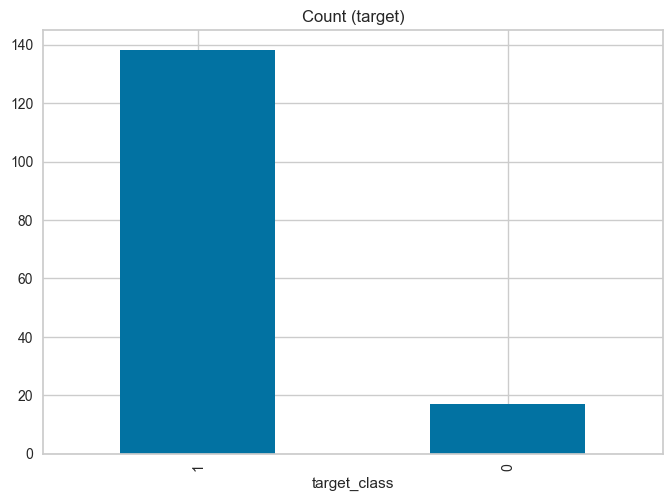

In [95]:
# classifier 2: GPU vs CPU Energy

clf2_features =clf_2_top
clf2_columns = clf2_features + ["target_class", "workload"]

df_clf_2 = df_cleaned
# Remove colums where gpu_cpu_energy is 1
df_clf_2 = df_clf_2[df_clf_2['gpu_cpu_energy'] != 1]  # Remove rows where gpu_cpu_energy == 1
df_clf_2 = df_clf_2.assign(target_class=np.where(df_clf_2['gpu_cpu_energy'] < 1, 0, 1))
df_clf_2 = df_clf_2.drop(columns=["cpu_time", "igpu_time", "gpu_time", "gpu_igpu", 
                                  "igpu_cpu", "gpu_cpu", "workload_name",
                                  "igpu_gpu"])

df_clf_2 = df_clf_2[clf2_columns]

forest_2_features = list(df_clf_2.columns)

df_clf_2['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)
df_clf_2 = df_clf_2.drop(columns=["workload"])



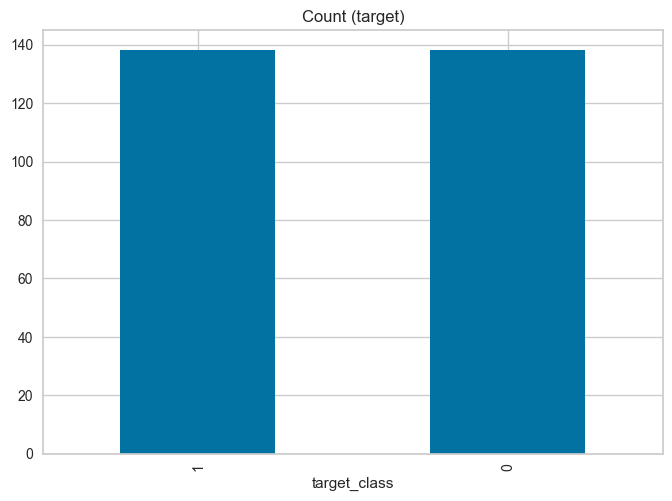

In [96]:
# SMOTE for imbalanced class
smote_df = df_clf_2.drop(columns=["target_class"])
smote = SMOTE(k_neighbors=3, sampling_strategy="auto", random_state=0)
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_2['target_class'])

df_clf_2 = pd.DataFrame(X_sm, columns=list(df_clf_2.columns))
df_clf_2['target_class'] = y_sm

df_clf_2['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

X_2 = df_clf_2.drop(columns=["target_class"])
X_columns = df_clf_2.columns
y_2 = df_clf_2["target_class"]


X_test = left_out[clf2_features+['gpu_cpu_energy']]
y_test = X_test.assign(target_class=np.where(X_test['gpu_cpu_energy'] < 1, 0, 1))
y_test = y_test["target_class"]
X_test = X_test.drop(columns = ['gpu_cpu_energy'])
 

In [97]:
X_2.columns

Index(['threads', 'global_memory_loads', 'global_memory_stores',
       'local_memory_loads', 'local_memory_stores', 'total_loops',
       'parallel_loops', 'cast_operations', 'vector_operations',
       'total_integer_operations'],
      dtype='object')

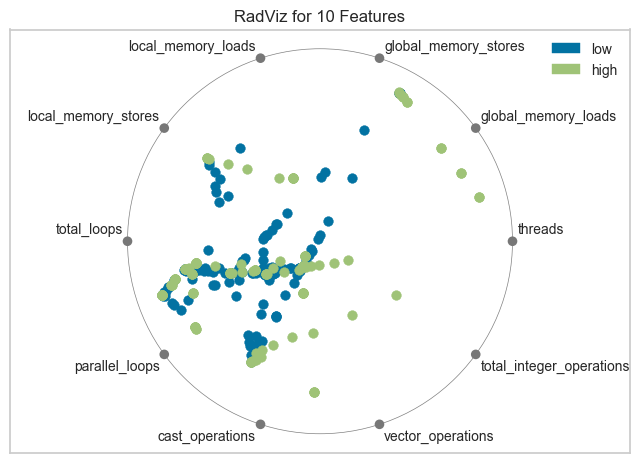

<Axes: title={'center': 'RadViz for 10 Features'}>

In [98]:
# Specify the target classes
classes = ["low", "high"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X_2, y_2)           # Fit the data to the visualizer
visualizer.transform(X_2)        # Transform the data
visualizer.show() 

0.6916666666666667 {'max_depth': 50, 'n_estimators': 100}
Top features:
1. feature 0: threads (0.3216996755657187)
2. feature 5: global_memory_loads (0.14027702124287458)
3. feature 2: global_memory_stores (0.11588479623373717)
4. feature 9: local_memory_loads (0.11002234697085683)
5. feature 6: local_memory_stores (0.10494425092749958)
6. feature 1: total_loops (0.08084797212010136)
7. feature 7: parallel_loops (0.05616971967422463)
8. feature 8: cast_operations (0.04328970892404457)
9. feature 3: vector_operations (0.013877358224232894)
10. feature 4: total_integer_operations (0.01298715011670964)
In-sample accuracy: 0.9927536231884058, Out-of-sample accuracy:0.8555555555555555


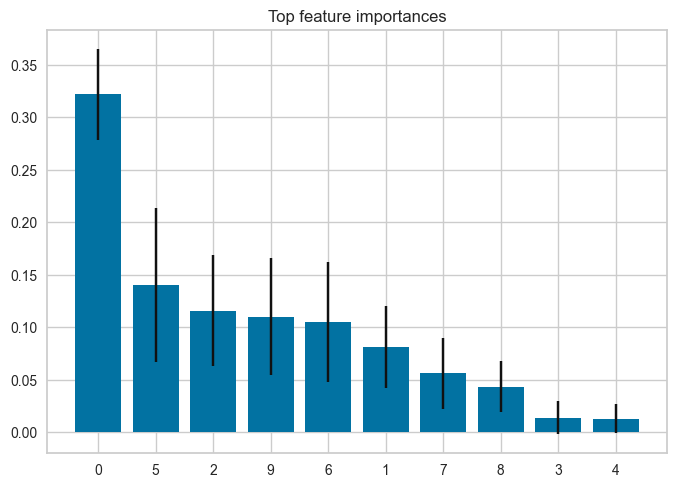

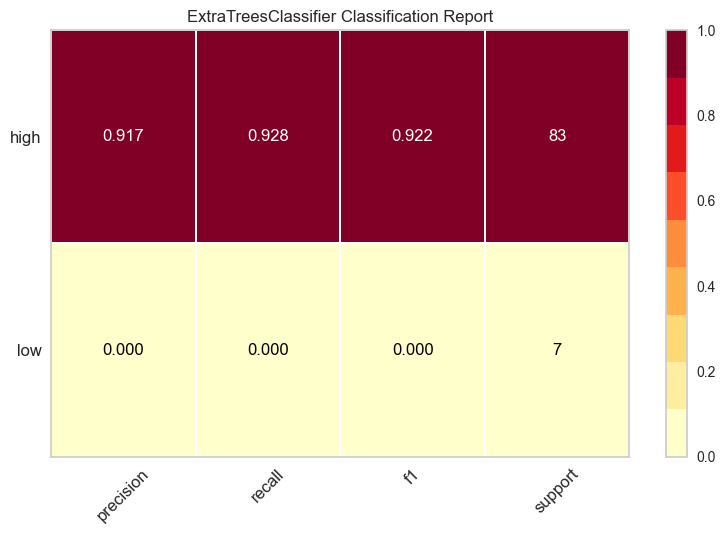

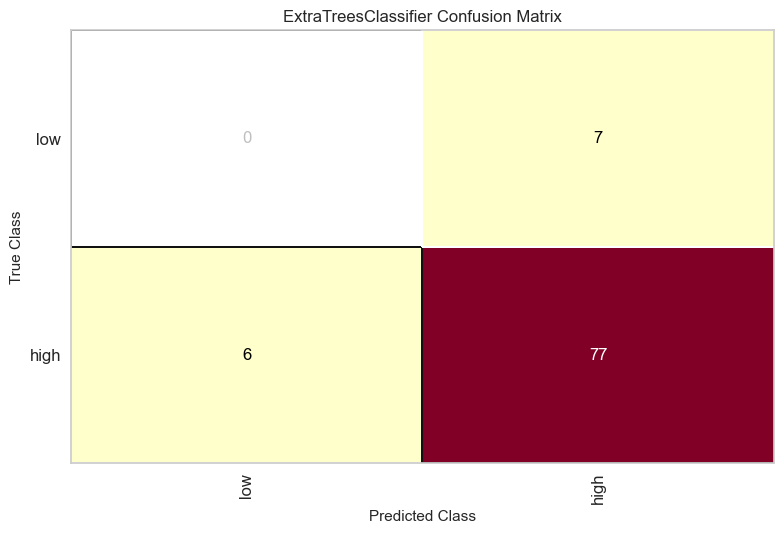

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [99]:
from sklearn.model_selection import GridSearchCV

train_cols = list(X_2.columns)

parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}

clf_2 = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf_2.fit(X_2, y_2)
forest_2 = clf_2.best_estimator_
print (clf_2.best_score_, clf_2.best_params_) 
forest_2.fit(X_2, y_2)

importances = forest_2.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_2.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')
    
# predict 
train_preds_2 = forest_2.predict(X_2)
test_preds_2 = forest_2.predict(X_test)

in_sample_acc_2 = accuracy_score(y_2, train_preds_2)
out_sample_acc_2 = accuracy_score(y_test, test_preds_2)

print(f"In-sample accuracy: {in_sample_acc_2}, Out-of-sample accuracy:{out_sample_acc_2}")

plt.figure()
plt.title('Top feature importances')
plt.bar(
    range(len(train_cols)), 
    importances[indices],
    yerr=std[indices], 
)
plt.xticks(range(len(train_cols)), indices)
plt.show()

# Classification Report
visualizer = ClassificationReport(forest_2, classes=["low", "high"], support=True)
visualizer.fit(X_2, y_2)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show() 

# Confusion Matrix
cm = ConfusionMatrix(forest_2, classes=["low", "high"])
cm.fit(X_2, y_2)
cm.score(X_test, y_test)
cm.show()

In [100]:
from sklearn.metrics import roc_curve
'''
y_probas = forest_2.predict_proba(X_test)
plot_roc(y_test, y_probas, title= "GPU vs CPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_2.pdf")
'''
# plt.show()

'\ny_probas = forest_2.predict_proba(X_test)\nplot_roc(y_test, y_probas, title= "GPU vs CPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_2.pdf")\n'

     pred_neg  pred_pos
neg         0         7
pos         2        81


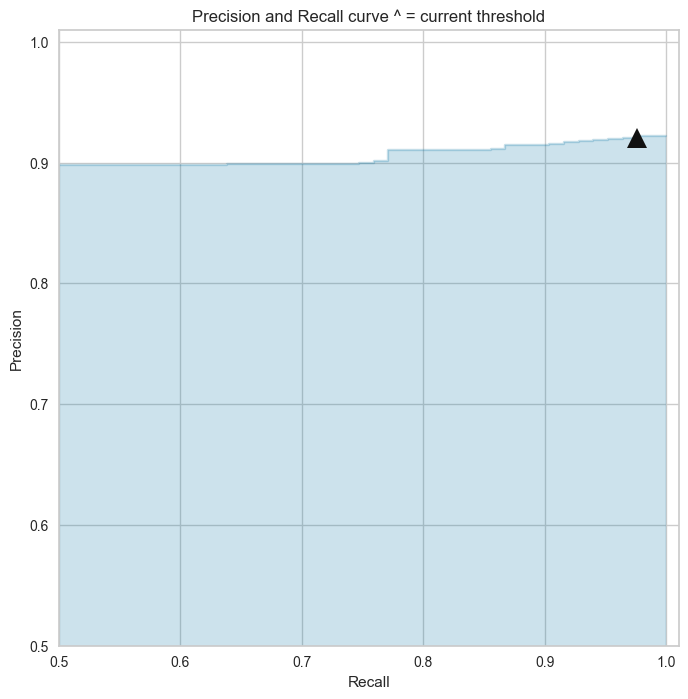

In [101]:
y_scores = forest_2.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0.1)

In [102]:
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]
clf_2_imp = [importances[i] for i in indices][:10]
clf_2_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_2_imp["model"] ="GPU vs CPU Energy"
clf_2_imp = clf_2_imp.set_index("model")


In [103]:
# Restore the predicted labels and actual labels corresponding to each sample in the test set.
X_test_copy_2 = X_test.copy()
X_test_copy_2["predicted"] = test_preds_2
X_test_copy_2["actual"] = y_test.values

# Optional: If you want to know which device is better (based on predicted labels)
# Prediction is 0 -> select iGPU, prediction is 1 -> select CPU
X_test_copy_2["recommended_device"] = np.where(X_test_copy_2["predicted"] == 1, "CPU", "iGPU")

In [104]:
# Save prediction results
# X_test_copy_2.to_csv("CPU_iGPU_Energy_device_recommendations.csv", index=False)

# Classifier 3: IGPU vs GPU

In [105]:
df_clf_3=df_cleaned
# Remove colums where gpu_igpu_energy is 1
df_clf_3 = df_clf_3[df_clf_3['gpu_igpu_energy'] != 1]  # Remove rows where gpu_igpu_energy == 1
df_clf_3 = df_clf_3.assign(target_class=np.where(df_clf_3['gpu_igpu_energy'] < 1, 0, 1))


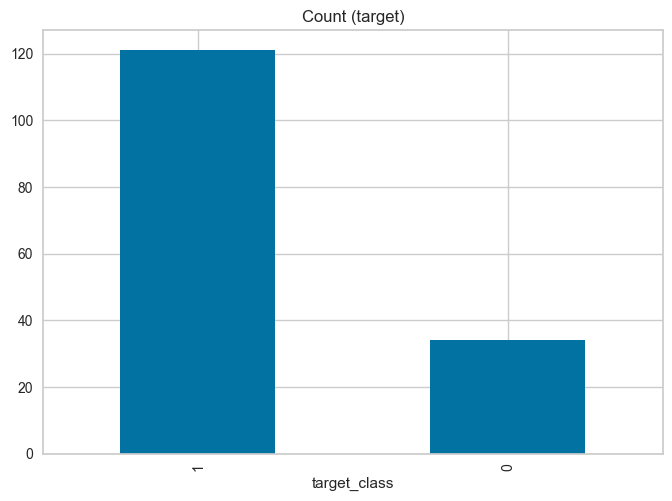

In [106]:
# classifier 3: GPU vs IGPU
# clf3_features = ["threads", "parallel_loops", "total_loops","cast_operations","local_memory_operations", 
#                  "global_memory_operations", "control_flow_operations", "total_float_operations",
#                 "math_functions"]


clf3_features=clf_3_top
clf3_columns = clf3_features + ["target_class", "workload"]

df_clf_3 = df_cleaned
# Remove colums where gpu_igpu_energy is 1
df_clf_3 = df_clf_3[df_clf_3['gpu_igpu_energy'] != 1]  # Remove rows where gpu_igpu_energy == 1
df_clf_3 = df_clf_3.assign(target_class=np.where(df_clf_3['gpu_igpu_energy'] < 1, 0, 1))
df_clf_3 = df_clf_3.drop(columns=["cpu_time", "igpu_time", "gpu_time", "gpu_igpu", 
                                  "igpu_cpu", "gpu_cpu", "workload_name",
                                  "igpu_gpu"])

df_clf_3 = df_clf_3[clf3_columns]

forest_3_features = list(df_clf_3.columns)

df_clf_3['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)
df_clf_3 = df_clf_3.drop(columns=["workload"])


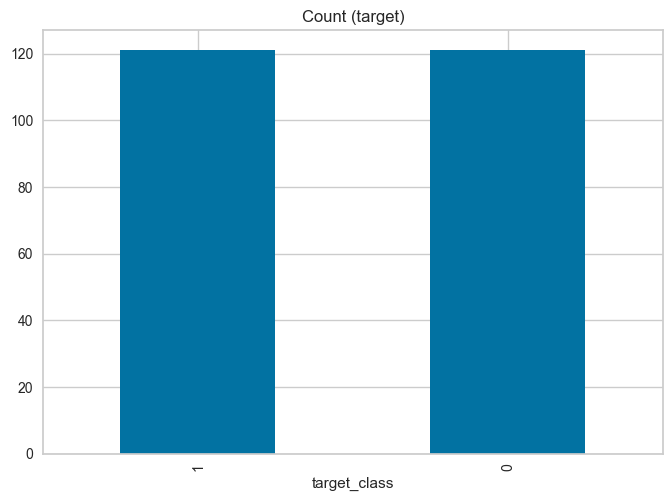

In [107]:
# SMOTE for imbalanced class
smote_df = df_clf_3.drop(columns=["target_class"])
smote = SMOTE(sampling_strategy = "auto", k_neighbors=8)
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_3['target_class'])

df_clf_3 = pd.DataFrame(X_sm, columns=list(df_clf_3.columns))
df_clf_3['target_class'] = y_sm

df_clf_3['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

X_3 = df_clf_3.drop(columns=["target_class"])
X_columns = df_clf_3.columns
y_3 = df_clf_3["target_class"]


X_test = left_out[clf3_features+['gpu_igpu_energy']]
X_test = X_test[X_test['gpu_igpu_energy'] != 1]  # Remove rows where gpu_igpu_energy == 1
y_test = X_test.assign(target_class=np.where(X_test['gpu_igpu_energy'] < 1, 0, 1))
y_test = y_test["target_class"]
X_test = X_test.drop(columns = ['gpu_igpu_energy'])
 

In [108]:
X_3.columns

Index(['threads', 'global_memory_loads', 'global_memory_stores',
       'local_memory_loads', 'local_memory_stores', 'total_loops',
       'parallel_loops', 'cast_operations', 'vector_operations',
       'total_integer_operations'],
      dtype='object')

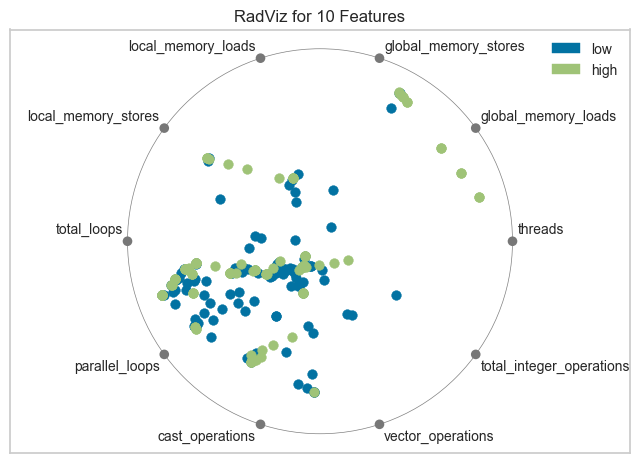

<Axes: title={'center': 'RadViz for 10 Features'}>

In [109]:
# Specify the target classes
classes = ["low", "high"]

# Instantiate the visualizer
visualizer = RadViz(classes=classes)

visualizer.fit(X_3, y_3)           # Fit the data to the visualizer
visualizer.transform(X_3)        # Transform the data
visualizer.show() 

0.5026666666666666 {'max_depth': 50, 'n_estimators': 100}
Top features:
1. feature 0: threads (0.4001140614702453)
2. feature 9: global_memory_loads (0.10597285889982135)
3. feature 8: global_memory_stores (0.10427397380170761)
4. feature 1: local_memory_loads (0.09191838751260967)
5. feature 5: local_memory_stores (0.09097621934593031)
6. feature 6: total_loops (0.08577618368691318)
7. feature 2: parallel_loops (0.07646526117251905)
8. feature 7: cast_operations (0.025100102036668764)
9. feature 4: vector_operations (0.009750465574844892)
10. feature 3: total_integer_operations (0.009652486498739862)
In-sample accuracy: 0.9834710743801653, Out-of-sample accuracy:0.7444444444444445


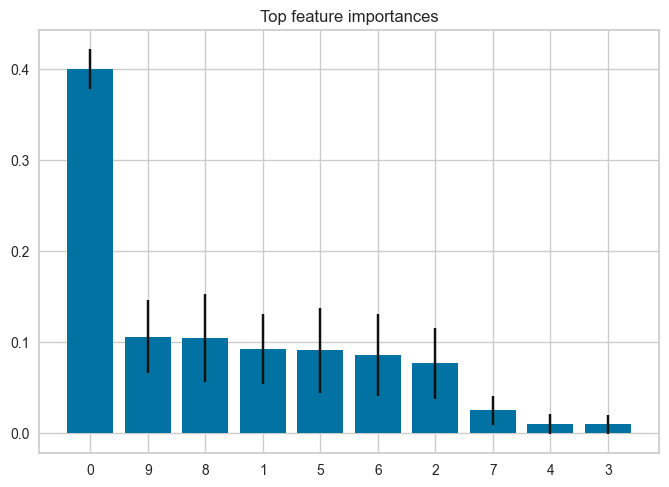

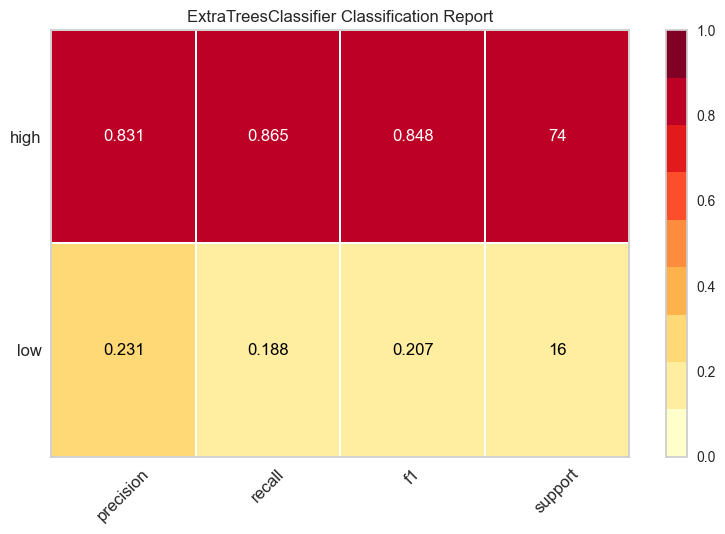

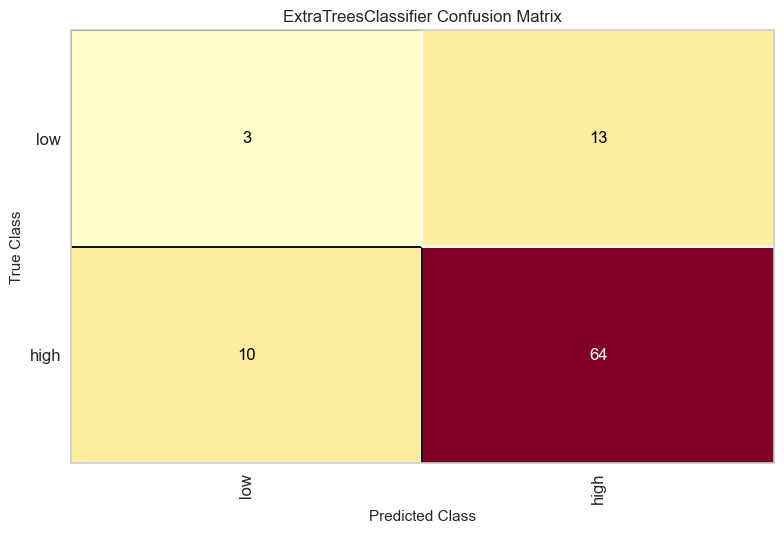

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [110]:
from sklearn.model_selection import GridSearchCV

train_cols = list(X_3.columns)

parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}

clf_3 = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf_3.fit(X_3, y_3)
forest_3 = clf_3.best_estimator_
print (clf_3.best_score_, clf_3.best_params_) 
forest_3.fit(X_3, y_3)

importances = forest_3.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_3.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')
    
# predict 
train_preds_3 = forest_3.predict(X_3)
test_preds_3 = forest_3.predict(X_test)

in_sample_acc_3 = accuracy_score(y_3, train_preds_3)
out_sample_acc_3 = accuracy_score(y_test, test_preds_3)

print(f"In-sample accuracy: {in_sample_acc_3}, Out-of-sample accuracy:{out_sample_acc_3}")

plt.figure()
plt.title('Top feature importances')
plt.bar(
    range(len(train_cols)), 
    importances[indices],
    yerr=std[indices], 
)
plt.xticks(range(len(train_cols)), indices)
plt.show()

# Classification Report
visualizer = ClassificationReport(forest_3, classes=["low", "high"], support=True)
visualizer.fit(X_3, y_3)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show() 

# Confusion Matrix
cm = ConfusionMatrix(forest_3, classes=["low", "high"])
cm.fit(X_3, y_3)
cm.score(X_test, y_test)
cm.show()

In [111]:
'''
y_probas = forest_3.predict_proba(X_test)
plot_roc(y_test, y_probas, title= "GPU vs IGPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_3.pdf")
'''
# plt.show()

'\ny_probas = forest_3.predict_proba(X_test)\nplot_roc(y_test, y_probas, title= "GPU vs IGPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_3.pdf")\n'

     pred_neg  pred_pos
neg         3        13
pos         6        68


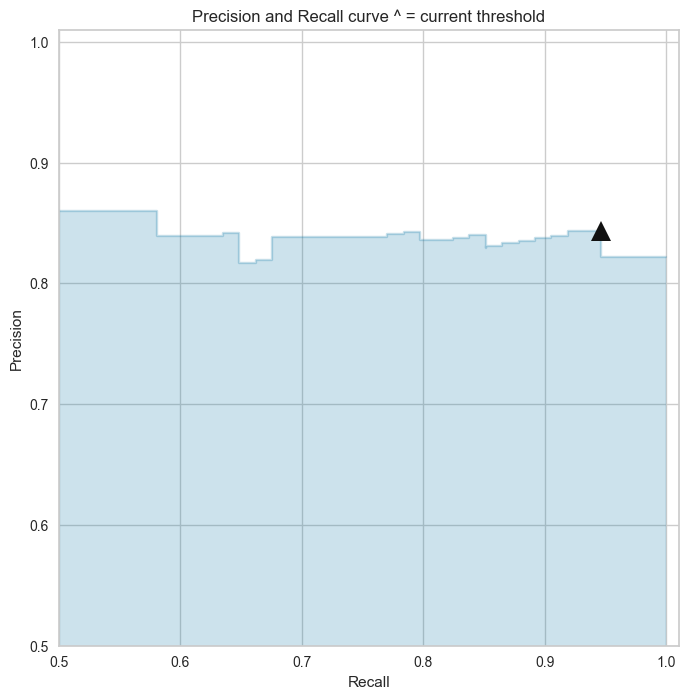

In [112]:
y_scores = forest_3.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0.1)

In [113]:
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]

clf_3_imp = [importances[i] for i in indices][:10]
clf_3_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_3_imp["model"] ="GPU vs IGPU Energy"
clf_3_imp = clf_3_imp.set_index("model")

In [114]:
# Restore the predicted labels and actual labels corresponding to each sample in the test set.
X_test_copy_3 = X_test.copy()
X_test_copy_3["predicted"] = test_preds_3
X_test_copy_3["actual"] = y_test.values

# Optional: If you want to know which device is better (based on predicted labels)
# Prediction is 0 -> select iGPU, prediction is 1 -> select CPU
X_test_copy_3["recommended_device"] = np.where(X_test_copy_3["predicted"] == 1, "GPU", "iGPU")

In [115]:
# Save prediction results
# X_test_copy_3.to_csv("iGPU_GPU_Energy_device_recommendations.csv", index=False)

# Classifier 4: Java vs CPU Energy

<Axes: title={'center': 'Count (target)'}, xlabel='target_class'>

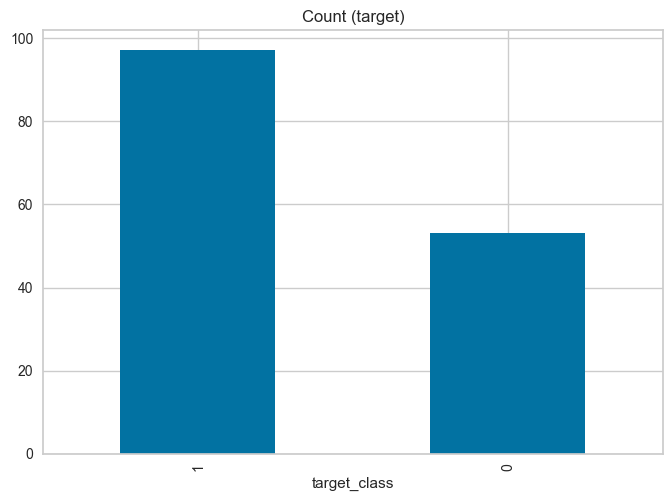

In [116]:
# Classifier 4 : Java vs CPU
# Create training set for classifier 4
df_clf_4=df_cleaned.copy()

# Remove colums where java_cpu_energy is 1
df_clf_4 = df_clf_4[df_clf_4['java_cpu_energy'] != 1]

# Create the target variable for classifier 4
df_clf_4 = df_clf_4.assign(target_class=np.where(df_clf_4['java_cpu_energy'] < 1, 0, 1))

# Select only clf_1_top features for training
clf4_features = clf_4_top
clf4_columns = clf_4_top + ["target_class"]
df_clf_4 = df_clf_4[clf4_columns]

# Barplot for the distribution of the target class
df_clf_4['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid =True)

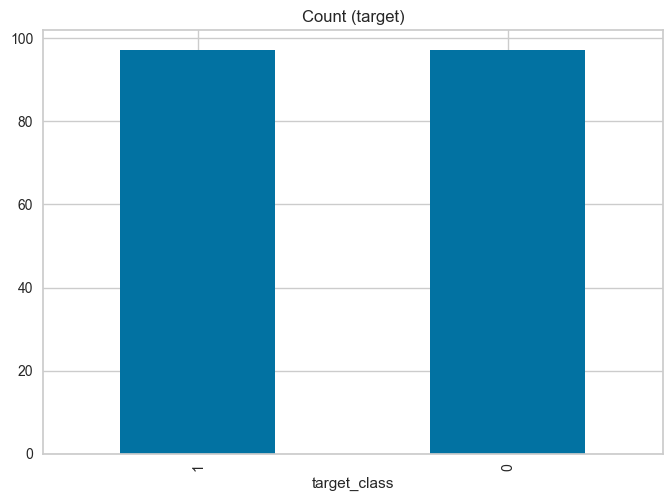

In [117]:
# From the barplot that was created it is evident that we have to deal with imbalanced data.
# This means that we have many more examples from class 1 (majority class) in the training dataset
# than from class 0 (minority class).
# This is going to affect negatively the training process and for this we are going to use the SMOTE
# in order to oversample the minority class

# Apply SMOTE
smote_df = df_clf_4.drop(columns=["target_class"])
smote = SMOTE(k_neighbors=8, sampling_strategy="auto", random_state=0)
'''
n_jobs: The number of threads to open when oversampling. If -1, then the number of threads is set to the number of CPU cores.
k_neighbors: The number of nearest neighbors to use when constructing synthetic samples.
sampling_strategy: The desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling.
random_state: The seed used by the random number generator.
'''
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_4['target_class'])

df_clf_4_balanced = pd.DataFrame(X_sm, columns=list(df_clf_4.columns))
df_clf_4_balanced['target_class'] = y_sm

# Compare with previous bar plot before SMOTE. Now we have balanced classes.
df_clf_4_balanced['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

# Final formatting of the training dataset
# X_1 is a pandas dataframe containing the features
# y_1 is a pandas series containg the target class
X_4 = df_clf_4_balanced.drop(columns=["target_class"])
X_columns = df_clf_4_balanced.columns
y_4 = df_clf_4_balanced["target_class"]

# Final formatting of the test dataset
# X_test is a pandas dataframe containing the features that the model expects
X_test = left_out[clf_4_top+['java_cpu_energy']]
X_test = X_test[X_test['java_cpu_energy'] != 1]  # Remove rows where java_cpu_energy == 1
y_test = X_test.assign(target_class=np.where(X_test['java_cpu_energy'] < 1, 0, 1))["target_class"]
X_test = X_test.drop(columns = ['java_cpu_energy'])

0.5257894736842104 {'max_depth': 50, 'n_estimators': 100}
Top features:
1. feature 0: threads (0.572717117297626)
2. feature 5: global_memory_loads (0.07771739574181635)
3. feature 7: global_memory_stores (0.07583007498538005)
4. feature 6: local_memory_loads (0.07055178842264881)
5. feature 1: local_memory_stores (0.059280218797185806)
6. feature 9: total_loops (0.052278041669410635)
7. feature 2: parallel_loops (0.04926851635256654)
8. feature 8: cast_operations (0.031223803957809205)
9. feature 3: vector_operations (0.005818389159014666)
10. feature 4: total_integer_operations (0.005314653616541871)
In-sample accuracy: 0.9845360824742269, Out-of-sample accuracy:0.686046511627907


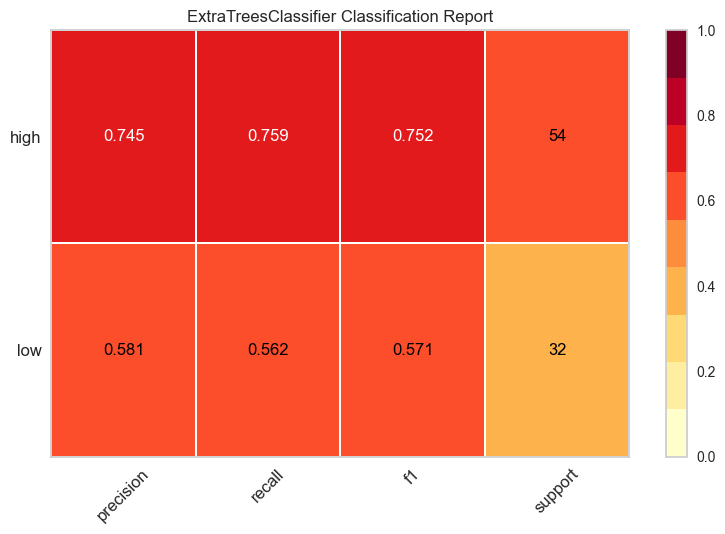

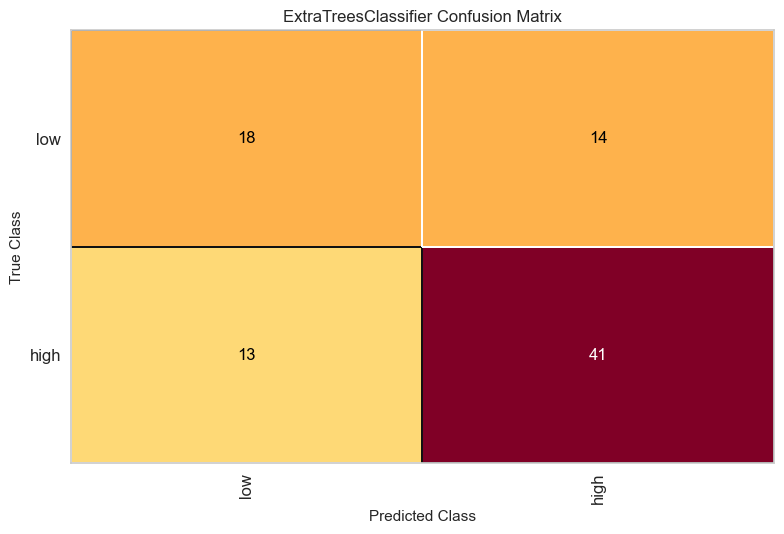

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [118]:
# from yellowbrick.classifier import ClassificationReport, ConfusionMatrix, ROCAUC
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_val_score

# Model training

train_cols = list(X_4.columns)
# Values per hyperparameter for grid search to search
parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}
# Apply grid search
clf = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf.fit(X_4, y_4)
# Get the best classifier found
forest_4 = clf.best_estimator_
print (clf.best_score_, clf.best_params_)
forest_4.fit(X_4, y_4)

# Get the feature importance order according to the trained classifier
importances = forest_4.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_4.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')

# Make predictions using the trained model for both train and test dataset
# in order to compute in-sample and out-of-sample accuracy
train_preds_4 = forest_4.predict(X_4)
test_preds_4 = forest_4.predict(X_test)

in_sample_acc_4 = accuracy_score(y_4, train_preds_4)
out_sample_acc_4 = accuracy_score(y_test, test_preds_4)
print(f"In-sample accuracy: {in_sample_acc_4}, Out-of-sample accuracy:{out_sample_acc_4}")

# Uncomment to plot feature importances
# plot_feature_importances(train_cols, indices)


# Classification Report
visualizer = ClassificationReport(forest_4, classes=["low", "high"], support=True)
visualizer.fit(X_4, y_4)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()

# Confusion Matrix
cm = ConfusionMatrix(forest_4, classes=["low", "high"])
cm.fit(X_4, y_4)
cm.score(X_test, y_test)
cm.show()

In [119]:
'''
y_probas = forest_4.predict_proba(X_test)
plot_roc(y_test, y_probas, title= "JAVA vs CPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_4.pdf")
'''
# plt.show()

'\ny_probas = forest_4.predict_proba(X_test)\nplot_roc(y_test, y_probas, title= "JAVA vs CPU ROC", class_labels=["Slowdown", "Speedup"], save_file="ROC_4.pdf")\n'

     pred_neg  pred_pos
neg        15        17
pos         2        52


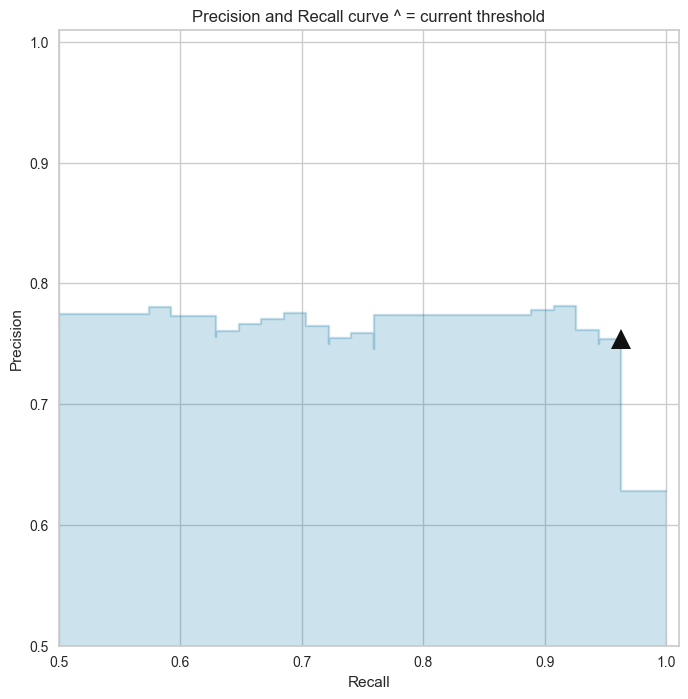

In [120]:
y_scores = forest_4.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0.1)

In [121]:
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]

clf_4_imp = [importances[i] for i in indices][:10]
clf_4_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_4_imp["model"] ="JAVA vs CPU Energy"
clf_4_imp = clf_4_imp.set_index("model")

In [122]:
# Restore the predicted labels and actual labels corresponding to each sample in the test set.
X_test_copy_4 = X_test.copy()
X_test_copy_4["predicted"] = test_preds_4
X_test_copy_4["actual"] = y_test.values

# Optional: If you want to know which device is better (based on predicted labels)
# Prediction is 0 -> select iGPU, prediction is 1 -> select CPU
X_test_copy_4["recommended_device"] = np.where(X_test_copy_4["predicted"] == 0, "Java", "CPU")

In [123]:
# Save prediction results
# X_test_copy_4.to_csv("Java_CPU_Energy_device_recommendations.csv", index=False)

# Classifier 5: Java vs GPU

<Axes: title={'center': 'Count (target)'}, xlabel='target_class'>

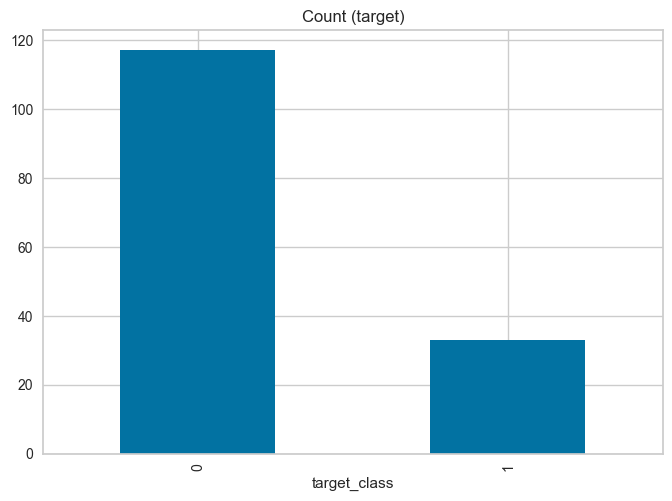

In [124]:
# Classifier 5 : Java vs GPU
# Create training set for classifier 5
df_clf_5=df_cleaned.copy()

# Remove colums where java_gpu_energy is 1
df_clf_5 = df_clf_5[df_clf_5['java_gpu_energy'] != 1]

# Create the target variable for classifier 1
df_clf_5 = df_clf_5.assign(target_class=np.where(df_clf_5['java_gpu_energy'] < 1, 0, 1))

# Select only clf_1_top features for training
clf5_columns = clf_5_top + ["target_class"]
df_clf_5 = df_clf_5[clf5_columns]

# Barplot for the distribution of the target class
df_clf_5['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid =True)


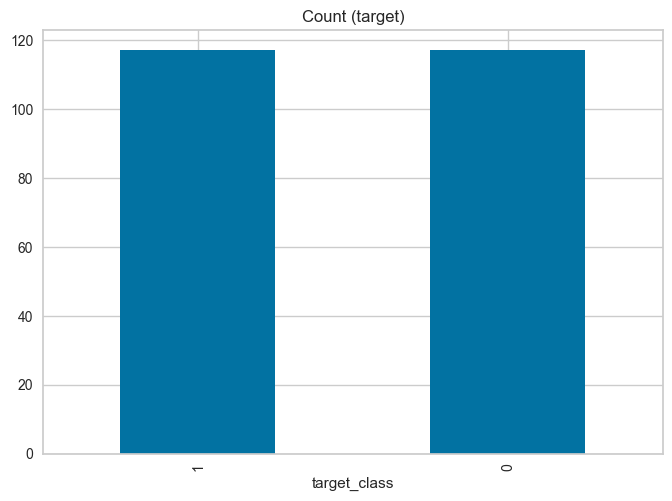

In [125]:
# From the barplot that was created it is evident that we have to deal with imbalanced data.
# This means that we have many more examples from class 1 (majority class) in the training dataset
# than from class 0 (minority class).
# This is going to affect negatively the training process and for this we are going to use the SMOTE
# in order to oversample the minority class

# Apply SMOTE
smote_df = df_clf_5.drop(columns=["target_class"])
smote = SMOTE(k_neighbors=8, sampling_strategy="auto", random_state=0)
'''
n_jobs: The number of threads to open when oversampling. If -1, then the number of threads is set to the number of CPU cores.
k_neighbors: The number of nearest neighbors to use when constructing synthetic samples.
sampling_strategy: The desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling.
random_state: The seed used by the random number generator.
'''
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_5['target_class'])

df_clf_5_balanced = pd.DataFrame(X_sm, columns=list(df_clf_5.columns))
df_clf_5_balanced['target_class'] = y_sm

# Compare with previous bar plot before SMOTE. Now we have balanced classes.
df_clf_5_balanced['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

# Final formatting of the training dataset
# X_1 is a pandas dataframe containing the features
# y_1 is a pandas series containg the target class
X_5 = df_clf_5_balanced.drop(columns=["target_class"])
X_columns = df_clf_5_balanced.columns
y_5 = df_clf_5_balanced["target_class"]

# Final formatting of the test dataset
# X_test is a pandas dataframe containing the features that the model expects
X_test = left_out[clf_5_top+['java_gpu_energy']]
X_test = X_test[X_test['java_gpu_energy'] != 1]  # Remove rows where java_gpu_energy == 1
y_test = X_test.assign(target_class=np.where(X_test['java_gpu_energy'] < 1, 0, 1))["target_class"]
X_test = X_test.drop(columns = ['java_gpu_energy'])


0.6335144927536233 {'max_depth': 50, 'n_estimators': 50}
Top features:
1. feature 0: threads (0.37643466637716366)
2. feature 9: global_memory_loads (0.10603590526941199)
3. feature 1: global_memory_stores (0.09280533931477292)
4. feature 8: local_memory_loads (0.09055634667094521)
5. feature 6: local_memory_stores (0.08217189608959842)
6. feature 2: total_loops (0.08120476002368429)
7. feature 5: parallel_loops (0.07994222551526205)
8. feature 7: cast_operations (0.048208987023319064)
9. feature 4: vector_operations (0.023496235149666755)
10. feature 3: total_integer_operations (0.019143638566175562)
In-sample accuracy: 0.9786324786324786, Out-of-sample accuracy:0.8023255813953488


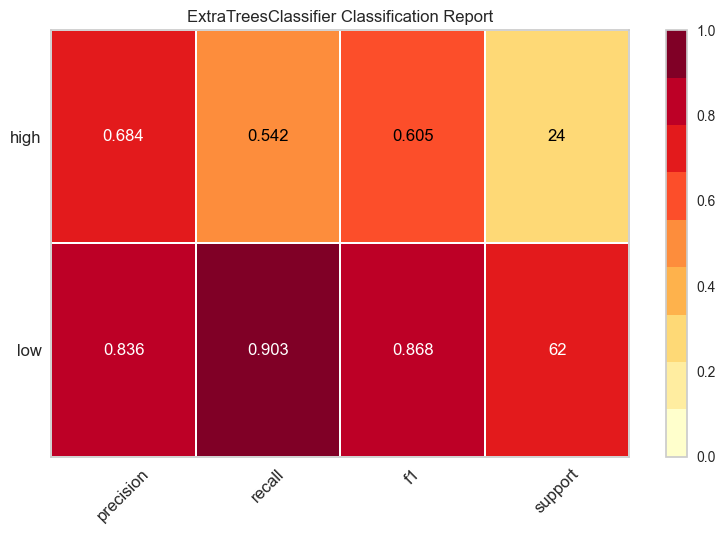

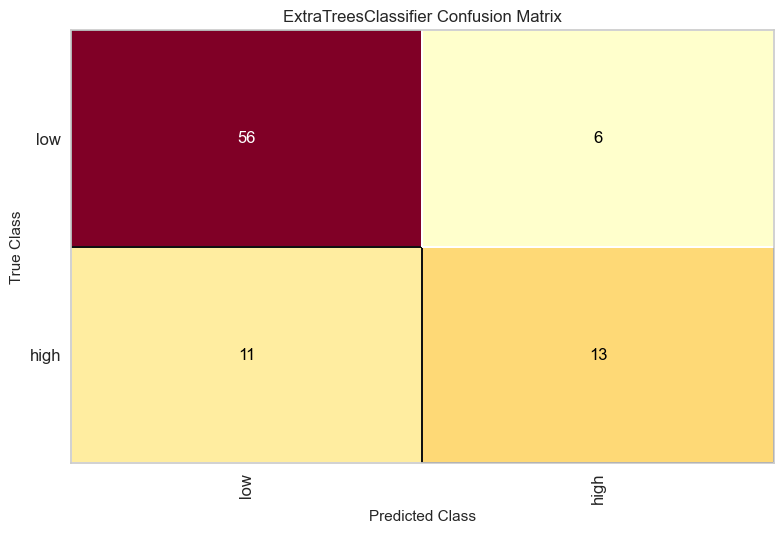

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [126]:
# from yellowbrick.classifier import ClassificationReport, ConfusionMatrix, ROCAUC
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_val_score

# Model training

train_cols = list(X_5.columns)
x_test = X_test[train_cols]
# Values per hyperparameter for grid search to search
parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}
# Apply grid search
clf = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf.fit(X_5, y_5)
# Get the best classifier found
forest_5 = clf.best_estimator_
print (clf.best_score_, clf.best_params_)
forest_5.fit(X_5, y_5)

# Get the feature importance order according to the trained classifier
importances = forest_5.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_5.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')

# Make predictions using the trained model for both train and test dataset
# in order to compute in-sample and out-of-sample accuracy
train_preds_5 = forest_5.predict(X_5)
test_preds_5 = forest_5.predict(X_test)

in_sample_acc_5 = accuracy_score(y_5, train_preds_5)
out_sample_acc_5 = accuracy_score(y_test, test_preds_5)
print(f"In-sample accuracy: {in_sample_acc_5}, Out-of-sample accuracy:{out_sample_acc_5}")

# Uncomment to plot feature importances
# plot_feature_importances(train_cols, indices)


# Classification Report
visualizer = ClassificationReport(forest_5, classes=["low", "high"], support=True)
visualizer.fit(X_5, y_5)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()

# Confusion Matrix
cm = ConfusionMatrix(forest_5, classes=["low", "high"])
cm.fit(X_5, y_5)
cm.score(X_test, y_test)
cm.show()


In [127]:
# create a dataframe with the per feature importance for classifier 1
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]
clf_5_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_5_imp["model"] ="Java vs GPU Energy"
clf_5_imp = clf_5_imp.set_index("model")

print(f"Importance per feature for classifier 1:")
clf_5_imp.head()


Importance per feature for classifier 1:


,threads,total_integer_operations,global_memory_loads,vector_operations,parallel_loops,global_memory_stores,total_loops,cast_operations,local_memory_stores,local_memory_loads
model,,,,,,,,,,
Java vs GPU Energy,0.376435,0.106036,0.092805,0.090556,0.082172,0.081205,0.079942,0.048209,0.023496,0.019144


     pred_neg  pred_pos
neg         0        62
pos         0        24


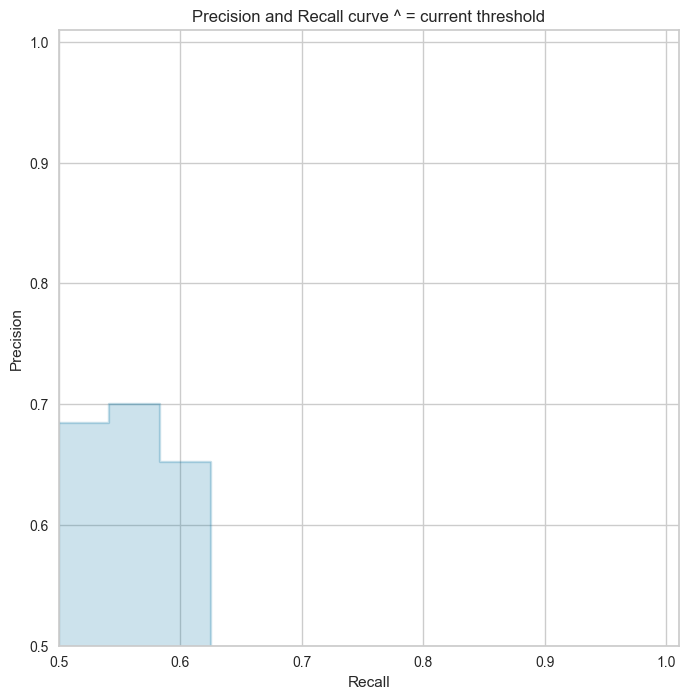

In [128]:
# ROC curve
y_scores = forest_5.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0)


In [129]:
# Restore the predicted labels and actual labels corresponding to each sample in the test set.
X_test_copy_5 = X_test.copy()
X_test_copy_5["predicted"] = test_preds_5
X_test_copy_5["actual"] = y_test.values

# Optional: If you want to know which device is better (based on predicted labels)
# Prediction is 0 -> select iGPU, prediction is 1 -> select CPU
X_test_copy_5["recommended_device"] = np.where(X_test_copy_5["predicted"] == 0, "Java", "GPU")

In [130]:
# Save prediction results
# X_test_copy_5.to_csv("Java_GPU_Energy_device_recommendations.csv", index=False)

# Classifier 6: Java vs iGPU

<Axes: title={'center': 'Count (target)'}, xlabel='target_class'>

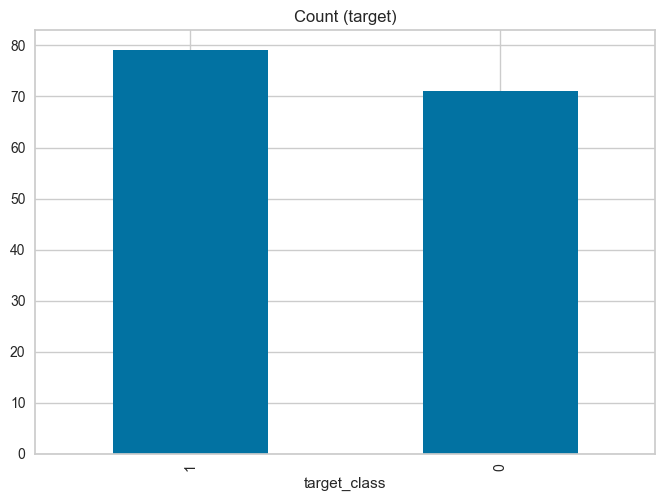

In [131]:
# Classifier 6 : Java vs iGPU
# Create training set for classifier 6
df_clf_6=df_cleaned.copy()

# Remove colums where java_igpu_energy is 1
df_clf_6 = df_clf_6[df_clf_6['java_igpu_energy'] != 1]

# Create the target variable for classifier 6
df_clf_6 = df_clf_6.assign(target_class=np.where(df_clf_6['java_igpu_energy'] < 1, 0, 1))

# Select only clf_6_top features for training
clf6_columns = clf_6_top + ["target_class"]
df_clf_6 = df_clf_6[clf6_columns]

# Barplot for the distribution of the target class
df_clf_6['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid =True)

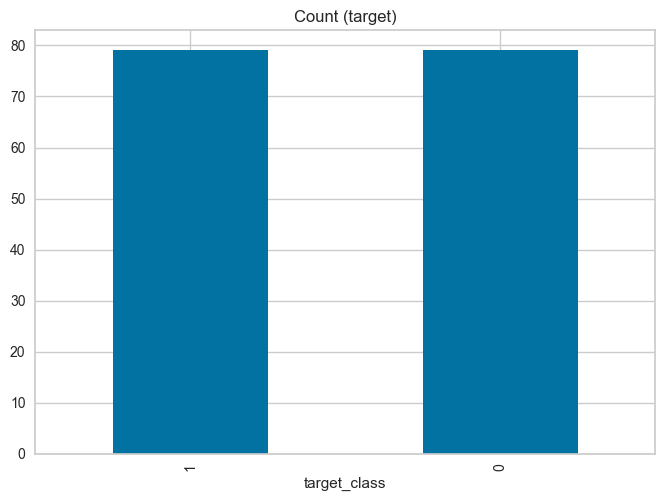

In [132]:

# From the barplot that was created it is evident that we have to deal with imbalanced data.
# This means that we have many more examples from class 1 (majority class) in the training dataset
# than from class 0 (minority class).
# This is going to affect negatively the training process and for this we are going to use the SMOTE
# in order to oversample the minority class

# Apply SMOTE
smote_df = df_clf_6.drop(columns=["target_class"])
smote = SMOTE(k_neighbors=8, sampling_strategy="auto", random_state=0)
'''
n_jobs: The number of threads to open when oversampling. If -1, then the number of threads is set to the number of CPU cores.
k_neighbors: The number of nearest neighbors to use when constructing synthetic samples.
sampling_strategy: The desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling.
random_state: The seed used by the random number generator.
'''
X_sm, y_sm = smote.fit_resample(smote_df, df_clf_6['target_class'])

df_clf_6_balanced = pd.DataFrame(X_sm, columns=list(df_clf_6.columns))
df_clf_6_balanced['target_class'] = y_sm

# Compare with previous bar plot before SMOTE. Now we have balanced classes.
df_clf_6_balanced['target_class'].value_counts().plot(kind='bar', title='Count (target)', grid=True)

# Final formatting of the training dataset
# X_6 is a pandas dataframe containing the features
# y_6 is a pandas series containg the target class
X_6 = df_clf_6_balanced.drop(columns=["target_class"])
X_columns = df_clf_6_balanced.columns
y_6 = df_clf_6_balanced["target_class"]

# Final formatting of the test dataset
# X_test is a pandas dataframe containing the features that the model expects
X_test = left_out[clf_6_top+['java_igpu_energy']]
X_test = X_test[X_test['java_igpu_energy'] != 1]  # Remove rows where java_igpu_energy == 1
y_test = X_test.assign(target_class=np.where(X_test['java_igpu_energy'] < 1, 0, 1))["target_class"]
X_test = X_test.drop(columns = ['java_igpu_energy'])


0.47625 {'max_depth': 10, 'n_estimators': 50}
Top features:
1. feature 0: threads (0.6086659317717575)
2. feature 6: global_memory_loads (0.0823085048824233)
3. feature 2: global_memory_stores (0.08143102173343225)
4. feature 7: local_memory_loads (0.047255385384213325)
5. feature 1: local_memory_stores (0.046620463154374875)
6. feature 9: total_loops (0.04341580546476397)
7. feature 8: parallel_loops (0.04149727342126926)
8. feature 5: cast_operations (0.03177279204779513)
9. feature 4: vector_operations (0.009413885448152115)
10. feature 3: total_integer_operations (0.00761893669181825)
In-sample accuracy: 0.9367088607594937, Out-of-sample accuracy:0.6976744186046512


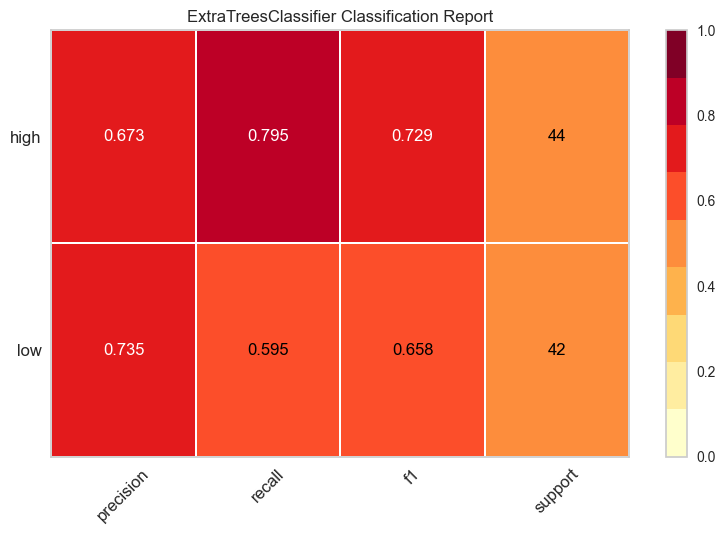

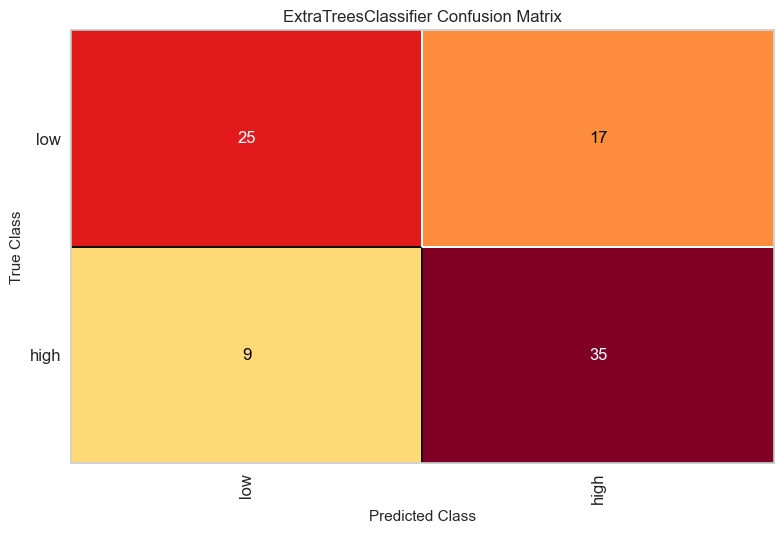

<Axes: title={'center': 'ExtraTreesClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [133]:
# from yellowbrick.classifier import ClassificationReport, ConfusionMatrix, ROCAUC
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_val_score

# Model training

train_cols = list(X_6.columns)
# Values per hyperparameter for grid search to search
parameters = {'n_estimators':[50, 100, 500, 1000], 'max_depth':[5, 10, 50, 100, 500]}
# Apply grid search
clf = GridSearchCV(ExtraTreesClassifier(random_state=0), parameters,cv=10)
clf.fit(X_6, y_6)
# Get the best classifier found
forest_6 = clf.best_estimator_
print (clf.best_score_, clf.best_params_)
forest_6.fit(X_6, y_6)

# Get the feature importance order according to the trained classifier
importances = forest_6.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in forest_6.estimators_],
    axis=0
)
indices = np.argsort(importances)[::-1]
indices = indices[:len(train_cols)]

print('Top features:')
for f in range(len(train_cols)):
    print(f'{f+1}. feature {indices[f]}: {train_cols[f]} ({importances[indices[f]]})')

# Make predictions using the trained model for both train and test dataset
# in order to compute in-sample and out-of-sample accuracy
train_preds_6 = forest_6.predict(X_6)
test_preds_6 = forest_6.predict(X_test)

in_sample_acc_6 = accuracy_score(y_6, train_preds_6)
out_sample_acc_6 = accuracy_score(y_test, test_preds_6)
print(f"In-sample accuracy: {in_sample_acc_6}, Out-of-sample accuracy:{out_sample_acc_6}")

# Uncomment to plot feature importances
# plot_feature_importances(train_cols, indices)


# Classification Report
visualizer = ClassificationReport(forest_6, classes=["low", "high"], support=True)
visualizer.fit(X_6, y_6)        # Fit the visualizer and the model
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()

# Confusion Matrix
cm = ConfusionMatrix(forest_6, classes=["low", "high"])
cm.fit(X_6, y_6)
cm.score(X_test, y_test)
cm.show()


In [134]:
# create a dataframe with the per feature importance for classifier 1
feature_order =[train_cols[i] for i in indices][:10]
feature_importances = [importances[i] for i in indices][:10]
clf_6_imp = pd.DataFrame(feature_importances, index=feature_order).T
clf_6_imp["model"] ="Java vs iGPU Energy"
clf_6_imp = clf_6_imp.set_index("model")

print(f"Importance per feature for classifier 1:")
clf_6_imp.head()


Importance per feature for classifier 1:


,threads,parallel_loops,global_memory_stores,cast_operations,global_memory_loads,total_integer_operations,vector_operations,total_loops,local_memory_stores,local_memory_loads
model,,,,,,,,,,
Java vs iGPU Energy,0.608666,0.082309,0.081431,0.047255,0.04662,0.043416,0.041497,0.031773,0.009414,0.007619


     pred_neg  pred_pos
neg         0        42
pos         0        44


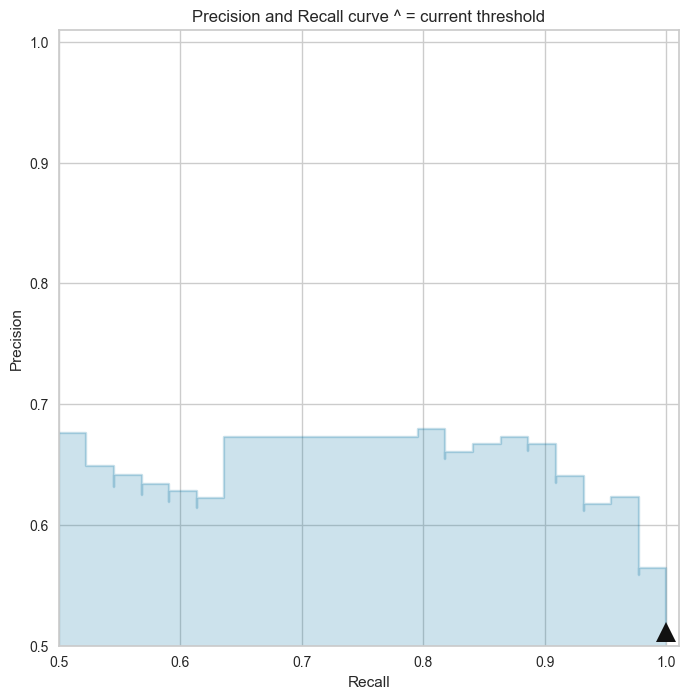

In [135]:
# ROC curve
y_scores = forest_6.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

precision_recall_threshold(p, r, y_test, y_scores, thresholds, 0)

In [136]:
# Restore the predicted labels and actual labels corresponding to each sample in the test set.
X_test_copy_6 = X_test.copy()
X_test_copy_6["predicted"] = test_preds_6
X_test_copy_6["actual"] = y_test.values

# Optional: If you want to know which device is better (based on predicted labels)
# Prediction is 0 -> select iGPU, prediction is 1 -> select CPU
X_test_copy_6["recommended_device"] = np.where(X_test_copy_6["predicted"] == 0, "Java", "iGPU")


In [137]:
# Save prediction results
# X_test_copy_6.to_csv("Java_iGPU_Energy_device_recommendations.csv", index=False)

# Evaluation in held-out data

In [138]:
# 0.3, 0.4, 0.7 => 8/9 >=baseline
#0.5, 0.4, 0.7

In [139]:
all_workloads = sum([workloads[k] for k in workloads], [])
test_set = left_out.set_index("workload").loc[all_workloads, :]

test_set = test_set.reset_index()



In [140]:
test_set = left_out.set_index("workload").loc[all_workloads, :]


In [141]:
workloads["workload_1_low"]=["sgemm_64", "matrixmultiplication1d_64", "matrixmultiplication2d_64", "dot-vector_1048576", "dot-image_256", "dft_256", "juliaset_512", "euler_16", "nbody_256"]
workloads["workload_1_medium"]=[ "sgemm_512", "matrixmultiplication1d_512", "matrixmultiplication2d_512", "dot-vector_4194304", "dot-image_1024", "dft_4096", "juliaset_2048", "euler_64", "nbody_4096"]
workloads["workload_1_high"]=["sgemm_4096", "matrixmultiplication1d_4096", "matrixmultiplication2d_4096", "dot-vector_33554432", "dot-image_8192", "dft_65536", "juliaset_8192", "euler_256", "nbody_32768"]

# Group 2: Mixed-Intensive
# Workloads are saxpy, hilbert, bfs, integration, rotate-vector, maxReductionGlobal, maxReductionLocal, vectorAdditionFloat4, blackAndWhiteFilter, renderTrack, rotate-image
workloads["workload_2_low"]=["saxpy_512", "hilbert_16", "bfs_256", "integration_65536", "rotate-vector_1048576", "maxreductionglobal_65536", "maxreductionlocal_65536", "vectoradditionfloat4_65536", "blackandwhitefilter_256", "rendertrack_64", "rotate-image_256"]
workloads["workload_2_medium"]=["saxpy_524288", "hilbert_256", "bfs_2048", "integration_2097152", "rotate-vector_4194304", "maxreductionglobal_4194304", "maxreductionlocal_2097152", "vectoradditionfloat4_2097152", "blackandwhitefilter_2048", "rendertrack_1024", "rotate-image_1024"]
workloads["workload_2_high"]=["saxpy_67108864", "hilbert_2048", "bfs_16384", "integration_67108864", "rotate-vector_33554432", "maxreductionglobal_67108864", "maxreductionlocal_67108864", "vectoradditionfloat4_67108864", "blackandwhitefilter_16384", "rendertrack_8192", "rotate-image_8192"]

# Group 3: Memory/Data-Intensive
# Workloads are vectorAddition, matrixVectorMultiplication, matrix addition, matrix transpose, convolve-array, convolve-image, stencil, blurFilter, add-image, blacksholes
workloads["workload_3_low"]=["vectoraddition_65536", "matrixvectormultiplication_64", "matrixaddition_64", "matrixtranspose_64", "convolve-array_64", "convolve-image_64", "stencil_65536", "blurfilter_256", "add-image_64", "blackscholes_512"]
workloads["workload_3_medium"]=["vectoraddition_2097152", "matrixvectormultiplication_512", "matrixaddition_512", "matrixtranspose_512", "convolve-array_1024", "convolve-image_1024", "stencil_2097152", "blurfilter_1024", "add-image_512", "blackscholes_131072"]
workloads["workload_3_high"]=["vectoraddition_67108864", "matrixvectormultiplication_4096", "matrixaddition_4096", "matrixtranspose_4096", "convolve-array_8192", "convolve-image_8192", "stencil_67108864", "blurfilter_8192", "add-image_4096", "blackscholes_67108864"]


'''
test_set = left_out.set_index("workload").loc[workloads[workload_experiment] , : ].loc[workloads[workload_experiment] , : ]

test_set_1 = test_set[list(X_1.columns)]

test_set_2 = test_set[list(X_2.columns)]

test_set_3 = test_set[list(X_3.columns)]

test_set_4 = test_set[list(X_4.columns)]

test_set_5 = test_set[list(X_5.columns)]

test_set_6 = test_set[list(X_6.columns)]
'''


'\ntest_set = left_out.set_index("workload").loc[workloads[workload_experiment] , : ].loc[workloads[workload_experiment] , : ]\n\ntest_set_1 = test_set[list(X_1.columns)]\n\ntest_set_2 = test_set[list(X_2.columns)]\n\ntest_set_3 = test_set[list(X_3.columns)]\n\ntest_set_4 = test_set[list(X_4.columns)]\n\ntest_set_5 = test_set[list(X_5.columns)]\n\ntest_set_6 = test_set[list(X_6.columns)]\n'

In [143]:
experiment_results = {}

for workload_group in workloads:
    workload_list = workloads[workload_group]
    test_set = left_out.set_index("workload").loc[workload_list, :].reset_index()

    test_set_meta = test_set[["workload"]]
    test_set_1 = test_set[list(clf1_reg.columns)]
    test_set_2 = test_set[list(X_2.columns)]
    test_set_3 = test_set[list(X_3.columns)]
    test_set_4 = test_set[list(X_4.columns)]
    test_set_5 = test_set[list(X_5.columns)]
    test_set_6 = test_set[list(X_6.columns)]

    test_set_meta["igpu_cpu_log_ratio"] = clf1_reg.predict(test_set_1)
    test_set_meta["gpu_cpu_high_efficiency"] = forest_2.predict_proba(test_set_2)[:, 1]
    test_set_meta["gpu_igpu_high_efficiency"] = forest_3.predict_proba(test_set_3)[:, 1]
    test_set_meta["java_cpu_high_efficiency"] = forest_4.predict_proba(test_set_4)[:, 1]
    test_set_meta["java_gpu_high_efficiency"] = forest_5.predict_proba(test_set_5)[:, 1]
    test_set_meta["java_igpu_high_efficiency"] = forest_6.predict_proba(test_set_6)[:, 1]

    test_set_meta["igpu_fit"] = (test_set_meta["igpu_cpu_log_ratio"] > 0).astype(int)
    test_set_meta["gpu_fit"] = np.where(test_set_meta['gpu_cpu_high_efficiency'] < 0.4, 0, 1)
    test_set_meta["gpu_igpu_fit"] = np.where(test_set_meta['gpu_igpu_high_efficiency'] < 0.67, 0, 1)
    test_set_meta["java_cpu_fit"] = np.where(test_set_meta['java_cpu_high_efficiency'] < 0.5, 0, 1)
    test_set_meta["java_gpu_fit"] = np.where(test_set_meta['java_gpu_high_efficiency'] < 0.5, 0, 1)
    test_set_meta["java_igpu_fit"] = np.where(test_set_meta['java_igpu_high_efficiency'] < 0.5, 0, 1)

    test_set_meta["device_code"] = (
            test_set_meta["igpu_fit"].astype(str)
            + test_set_meta["gpu_fit"].astype(str)
            + test_set_meta["gpu_igpu_fit"].astype(str)
    )

    def resolve_device_full(row):
        code = row["device_code"]
        if code in ['000', '001']:
            base = 'cpu'
        elif code in ['100', '101', '110']:
            base = 'igpu'
        elif code in ['010', '011', '111']:
            base = 'gpu'
        else:
            base = 'unknown'

        if base == 'cpu':
            return 'java' if row['java_cpu_fit'] == 0 else 'cpu'
        elif base == 'igpu':
            return 'java' if row['java_igpu_fit'] == 0 else 'igpu'
        elif base == 'gpu':
            return 'java' if row['java_gpu_fit'] == 0 else 'gpu'
        else:
            return 'unknown'

    test_set_meta["final_device"] = test_set_meta.apply(resolve_device_full, axis=1)

    # Save to dictionary
    scheduling = dict(zip(test_set_meta.workload, test_set_meta.final_device))
    experiment_results[workload_group] = scheduling

    # Optional: save individual CSV
    # test_set_meta.to_csv(f"energy_truth_table_{workload_group}.csv", index=False)


AttributeError: 'RandomForestRegressor' object has no attribute 'columns'

In [73]:
# Combine all results into one big CSV
df_all = pd.DataFrame([
    {"workload_group": group, "workload": wl, "final_device": device}
    for group, group_data in experiment_results.items()
    for wl, device in group_data.items()
])

df_all.to_csv("energy_experiment_results_all.csv", index=False)


In [74]:
'''
test_set_1=test_set_1.reset_index()
test_set_meta=test_set_1[["workload"]]
test_set_1 = test_set_1.drop(columns=["workload"])
test_set_meta
'''

'\ntest_set_1=test_set_1.reset_index()\ntest_set_meta=test_set_1[["workload"]]\ntest_set_1 = test_set_1.drop(columns=["workload"])\ntest_set_meta\n'

In [75]:
'''
test_set_meta["igpu_cpu_high_speedup"] = list(pd.DataFrame(forest_1.predict_proba(test_set_1), columns=forest_1.classes_)[1])
test_set_meta["gpu_cpu_high_speedup"] = list(pd.DataFrame(forest_2.predict_proba(test_set_2), columns=forest_2.classes_)[1])
test_set_meta["gpu_igpu_high_speedup"] = list(pd.DataFrame(forest_3.predict_proba(test_set_3), columns=forest_3.classes_)[1])

test_set_meta = test_set_meta.assign(igpu_fit=np.where(test_set_meta['igpu_cpu_high_speedup'] < 0.15, 0, 1))
test_set_meta = test_set_meta.assign(gpu_fit=np.where(test_set_meta['gpu_cpu_high_speedup'] < 0.4, 0, 1))
test_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta['gpu_igpu_high_speedup'] < 0.67, 0, 1))

# test_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta['gpu_cpu_high_speedup'] < test_set_meta['igpu_cpu_high_speedup'], 0, 1))

test_set_meta["device"]=test_set_meta["igpu_fit"].map(str)+test_set_meta["gpu_fit"].map(str)+test_set_meta["gpu_igpu_fit"].map(str)
# test_set_meta["device"]=test_set_meta["igpu_fit"].map(str)+test_set_meta["gpu_fit"].map(str)


test_set_meta["device"]=test_set_meta['device'].replace(['001', '000'], 'cpu')
test_set_meta["device"]=test_set_meta['device'].replace(['101', '100', '110'], 'igpu')
test_set_meta["device"]=test_set_meta['device'].replace(['011', '010', '111'], 'gpu')

# test_set_meta["device"]=test_set_meta['device'].replace(['00'], 'cpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['10'], 'igpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['01', '11'], 'gpu')
# test_set_meta["device"]=test_set_meta['device'].replace(['11'], 'gpu')

# test_set_meta['device'] = np.where(((test_set_meta['device']=='gpu')
#                                    & (test_set_meta['igpu_cpu_high_speedup']> test_set_meta['igpu_cpu_high_speedup'])), 'igpu', 'gpu')
'''


'\ntest_set_meta["igpu_cpu_high_speedup"] = list(pd.DataFrame(forest_1.predict_proba(test_set_1), columns=forest_1.classes_)[1])\ntest_set_meta["gpu_cpu_high_speedup"] = list(pd.DataFrame(forest_2.predict_proba(test_set_2), columns=forest_2.classes_)[1])\ntest_set_meta["gpu_igpu_high_speedup"] = list(pd.DataFrame(forest_3.predict_proba(test_set_3), columns=forest_3.classes_)[1])\n\ntest_set_meta = test_set_meta.assign(igpu_fit=np.where(test_set_meta[\'igpu_cpu_high_speedup\'] < 0.15, 0, 1))\ntest_set_meta = test_set_meta.assign(gpu_fit=np.where(test_set_meta[\'gpu_cpu_high_speedup\'] < 0.4, 0, 1))\ntest_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta[\'gpu_igpu_high_speedup\'] < 0.67, 0, 1))\n\n# test_set_meta = test_set_meta.assign(gpu_igpu_fit=np.where(test_set_meta[\'gpu_cpu_high_speedup\'] < test_set_meta[\'igpu_cpu_high_speedup\'], 0, 1))\n\ntest_set_meta["device"]=test_set_meta["igpu_fit"].map(str)+test_set_meta["gpu_fit"].map(str)+test_set_meta["gpu_igpu_fit"

In [76]:
# test_set_meta

In [77]:
# scheduling = dict(zip(test_set_meta.workload, test_set_meta.device))

In [78]:
# experiment_results[workload_experiment] = scheduling

In [79]:
# experiment_results

In [80]:
'''from joblib import dump, load
dump(forest_1, 'IGPUvsCPU_final.joblib') 
dump(forest_2, 'GPUvsCPU_final.joblib') 
dump(forest_3, 'GPUvsIGPU_final.joblib')
'''

"from joblib import dump, load\ndump(forest_1, 'IGPUvsCPU_final.joblib') \ndump(forest_2, 'GPUvsCPU_final.joblib') \ndump(forest_3, 'GPUvsIGPU_final.joblib')\n"

In [81]:
'''
classifier_features = {
    "c1": list(X_1.columns),
    "c2": list(X_2.columns),
    "c3": list(X_3.columns)
}

with open('./Final Artifacts/features.txt', 'w') as outfile:
    json.dump(classifier_features, outfile)
'''

'\nclassifier_features = {\n    "c1": list(X_1.columns),\n    "c2": list(X_2.columns),\n    "c3": list(X_3.columns)\n}\n\nwith open(\'./Final Artifacts/features.txt\', \'w\') as outfile:\n    json.dump(classifier_features, outfile)\n'

# Plots

In [82]:
feat_imp = pd.concat([clf_1_imp,clf_2_imp, clf_3_imp, clf_4_imp, clf_5_imp, clf_6_imp], axis=0).fillna(0)
feat_imp

,threads,total_loops,global_memory_loads,total_integer_operations,global_memory_stores,parallel_loops,cast_operations,vector_operations,local_memory_stores,local_memory_loads
model,,,,,,,,,,
IGPU vs CPU Energy,0.628981,0.059916,0.056804,0.055384,0.054341,0.052396,0.044196,0.036122,0.005935,0.005925
GPU vs CPU Energy,0.321700,0.140277,0.080848,0.110022,0.115885,0.104944,0.056170,0.043290,0.012987,0.013877
GPU vs IGPU Energy,0.203386,0.132278,0.122068,0.093845,0.092953,0.129364,0.035779,0.143511,0.022214,0.024603
JAVA vs CPU,0.572717,0.077717,0.059280,0.052278,0.049269,0.070552,0.075830,0.031224,0.005315,0.005818
Java vs GPU Energy,0.376435,0.079942,0.092805,0.106036,0.081205,0.082172,0.048209,0.090556,0.023496,0.019144
Java vs iGPU Energy,0.608666,0.031773,0.046620,0.043416,0.081431,0.082309,0.047255,0.041497,0.009414,0.007619


In [83]:
def hinton(matrix, max_weight=None, ax=None):
    """Draw Hinton diagram for visualizing a weight matrix."""
    ax = ax if ax is not None else plt.gca()

    if not max_weight:
        max_weight = 2**np.ceil(np.log(np.abs(matrix).max())/np.log(2))

    ax.patch.set_facecolor('white')
    ax.set_aspect('equal', 'box')
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    for (x, y), w in np.ndenumerate(matrix):
        color = 'black' if w > 0 else 'blue'
        size = np.sqrt(np.abs(w))
        rect = plt.Rectangle([x - size / 2, y - size / 2], size, size,
                             facecolor=color, edgecolor=color)
        ax.add_patch(rect)
        
    for spine in ax.spines.values():
        spine.set_color('lightgray')

    xticks = matrix.shape[0]
    yticks = matrix.shape[1]
    ax.xaxis.tick_top()
    ax.set_xticks(range(xticks))
    ax.set_xticklabels(list(matrix.index), rotation=80, fontsize=15)
    ax.set_yticks(range(yticks))
    ax.set_yticklabels(list(matrix.columns),  rotation=0, fontsize=14)
#     ax.grid(True)
    plt.grid(True)

    ax.autoscale_view()
    ax.invert_yaxis()
    plt.tight_layout()
    '''
    plt.savefig('feature_importances.pdf', bbox_inches='tight')
    '''

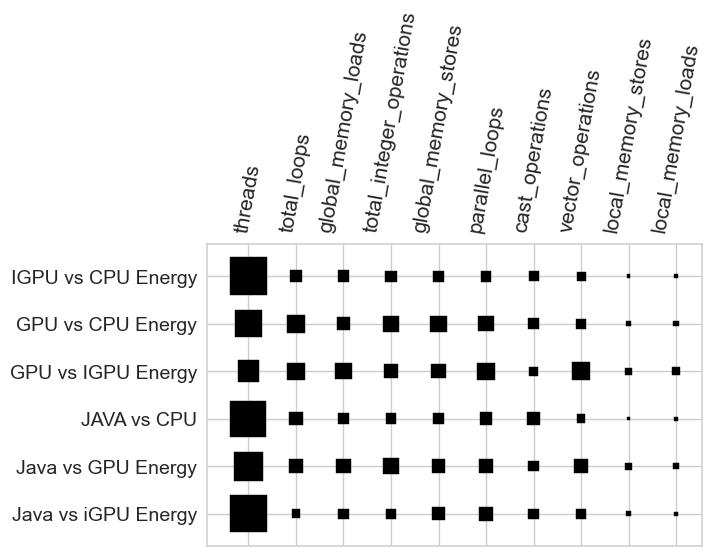

In [84]:
hinton(feat_imp.T)